In [9]:
# Import modules

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Sci computing
import numpy as np
import scipy as sp
import seawater as sw
import scipy.sparse.linalg as sla
from contourpy import contour_generator
import pyfftw 

# Importing bathymetry (tiff)
import rasterio as geo

# Parallel comupting
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

# For Data
import netCDF4 as nc
import xarray as xr

# Plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grdspc
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cmocean as cm

# Gen stuff
from datetime import date
today = date.today()

In [2]:
# For plotting; have the bathymetry of the gulf

ds_gulf = geo.open('/home/justin_cooke_uri_edu/DeepCyclones/gulf.tiff')
#ds_gulf = geo.open('../gulf.tiff')
img = ds_gulf.read(1)

(gm,gn) = np.shape(img)
gulf_lon = np.linspace(-90,-82,gn)
gulf_lat = np.linspace(22,28,gm)

# To get the aspect ratio right
ymid = np.mean(gulf_lat)
ymid_rad = ymid*np.pi/180

# For plotting: labels

lon_xticks = np.array((-90,-89,-88,-87,-86,-85,-84,-83))
lon_xticklbls = ['$90^\circ$W','$89^\circ$W','$88^\circ$W','$87^\circ$W','$86^\circ$W','$85^\circ$W','$84^\circ$W','$83^\circ$W']

lat_yticks = np.array((22,23,24,25,26,27,28))
lat_yticklbls = ['$22^\circ$N','$23^\circ$N','$24^\circ$N','$25^\circ$N','$26^\circ$N','$27^\circ$N','$28^\circ$N']

In [3]:
ds_eref = xr.open_mfdataset('./hycom_data/hycom_etaref_*.nc',combine='nested',concat_dim='MT')
ds_ssh = xr.load_dataset('./hycom_data/hycom_ssh_filtered.nc')

In [4]:
# Load the variables we care about
eref = ds_eref['eta_ref']
ssh = ds_ssh['ssh']
esteric = ssh - eref
ssh_demean = ssh - xr.DataArray.mean(ssh,dim=["Latitude","Longitude"],skipna=True)
esteric_demean = esteric - xr.DataArray.mean(esteric,dim=["Latitude","Longitude"],skipna=True)
ssha = ssh_demean - xr.DataArray.mean(ssh_demean,dim=['MT'],skipna=True)

lon = ds_eref['Longitude']
lat = ds_eref['Latitude']

Nt,Nlat,Nlon = eref.shape

**FUNCTIONS**

In [5]:
# CEOF Function

def c_eof(D,NOE=10):
    # This function determines the complex empirical orthogonal functions of a data set contained in matrix D

    # INPUTS:
    # D: Each row is assumed to be a sample; each column a variable. Thus, a column represents a time-series of one variable (or at one point)
    # NOE: Number of Eigenvalues (optional, if non-given then NOE=10)

    # OUTPUTS:
    # V: Vector of real eigenvalues 
    # EOFs: Matrix with complex values, each column represents an EOF
    # EC: EOF coefficients, also called principal component coefficients, i.e., the original time-series transformed to EOF space
    # error: The L2-norm of the reconstruction error of each point

    # Written by Justin Cooke, 2025, based on the MATLAB code written by Martijn Hooimeijer, 1999.

    # n = number of spatial points, m = number of time steps
    (n,m) = np.shape(D)
    q = np.min((n,m))

    # Hilbert transform the D matrix 
    def hilbtrans(X):

        # Now we will enter the frequency domain
        # Conduct the fft, using pyfftw so that we use an fftw library wrapper
        Y = pyfftw.interfaces.scipy_fft.fft(X,axis=0) # Need to set the axis to be zero to go along the first axis

        # Get the shape 
        (p,q) = np.shape(Y)
        N = p 
        # print('N = ',N)
        N2 = np.floor(N/2) - 1 # effect of odd and even # of elements
        # N2 = np.array(np.floor(N/2),dtype=np.int16)
        N2 = int(N2)
        # print('N2 = ',N2)

        # Now, rotate the first half of the matrix
        #print('Rotating the first half of the matrix CCW 90 degrees ...')
        P = np.zeros((p,q),dtype=complex) # Allocate a complex matrix, P, to be filled
        P[0:(N2),:] = Y[0:(N2),:]*1j
        #print('Here is the first half of P: ','\n',P[0:(N2),:])

        N2 = N - N2
        N2 = int(N2)
        #print('New N2 = ',N2)

        P[N2:,:] = Y[N2:,:]/1j
        #print('Second half of P = ','\n',P[N2:N])

        # Now we need to go back to the time domain using ifft
        XH = pyfftw.interfaces.scipy_fft.ifft(P,axis=0,norm='backward')

        # XH will most likely return something that has the same real part as MATLAB, but small differences in the complex part
        
        return XH
    
    # Hilbert transform of the data matrix, D
    DH = hilbtrans(D)
    

    # Allocate memory for a complex matrix, DC, which is the original matrix, D, plus the hilbert transform of that matrix
    DC = np.zeros((n,m),dtype='complex')
    DC = D + DH*1j

    def EOF2(D,p): # Computes the eigenvalues, EOFs, and EOF Coefficients, input is D and the number of eigenvalues (NOE)
        
        (m,n) = np.shape(D) 
        Ma = np.sum(D,axis=0)/m # Find the average of each time-series (column)
        DS = D - np.tile(Ma,(m,1)) # Remove this average to make each time-series have zero-mean
        q = np.min((m,n)) # What is smaller, the time series of the number of data points?

        NOE = min(q,p) # NOE will either be the smallest number b/t the size and the inputted NOE

        if m >= n:
            CE = (DS.conj().T @ DS) / (m-1)
            if np.isscalar(CE):
                (S,EOFs) = sla.eigs(CE,NOE)
            else:
                (S,EOFs) = sla.eigs(A=CE,k=NOE,M=np.eye(n,n),return_eigenvectors=True)

        if m < n:
            CE = (DS @ DS.conj().T) / (m-1)
            (S,E) = sla.eigs(A=CE,k=NOE,M=np.eye(m,m))
            EOFs = DC.conj().T @ E
            for i in range(NOE):
                EOFs[:,i]  = EOFs[:,i] / np.linalg.norm(EOFs[:,i])

        V = (np.real(S))

        EC = DS @ EOFs

        diff = (DS - (EC @ EOFs.conj().T))

        error = np.sqrt(np.sum(np.abs(np.pow(diff,2)),axis=0))
        # print(error)
            
        return(V,EOFs,EC,error)

    (V,EOFs,EC,error) = EOF2(DC,NOE)

    return(V,EOFs,EC,error)


# Low Pass Filter

from scipy.signal import butter, filtfilt

def lowpassfilt(data, filtT, sampT):
    """
    Low-pass filter a 1D data vector using a second-order Butterworth filter.
    Filtering is applied forward and backward to eliminate phase shift.

    Parameters
    ----------
    data : array_like
        Input data vector (1D array). Can be row or column oriented.
    filtT : float
        Filter period (same units as sampT).
    sampT : float
        Sampling period (same units as filtT).

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape as input.
    """

    data = np.asarray(data)
    if data.ndim != 1:
        raise ValueError("Input must be a 1D vector, not an array.")

    # Check if input was a row vector (for shape preservation)
    was_row = data.ndim == 1 and data.shape[0] < data.shape[-1]

    # Remove linear trend between endpoints
    n = len(data)
    x = np.arange(1, n + 1)
    p = np.polyfit([1, n], [data[0], data[-1]], 1)
    lineartrend = np.polyval(p, x)
    detrended = data - lineartrend

    # Check for NaNs
    if np.isnan(detrended).any():
        raise ValueError("Data contains NaNs; remove them before filtering.")

    # Butterworth filter setup
    # Wn is the normalized cutoff frequency (Nyquist = 0.5 / sampT)
    Wn = (2.0 / filtT) * sampT
    if Wn >= 1:
        raise ValueError("Cutoff frequency too high; ensure filtT > 2 * sampT.")
    b, a = butter(2, Wn)

    # Zero-phase filtering
    filtered = filtfilt(b, a, detrended)

    # Add linear trend back
    out = filtered + lineartrend

    # Preserve input orientation
    if was_row:
        out = out.reshape(1, -1)
    else:
        out = out.reshape(-1)

    return out


# Band-pass filter

def butterfilt_bandpass(x, order, filtThi, filtTlo, sampT):
    """
    Band-pass Butterworth filter with zero-phase (forward–reverse) filtering.

    Parameters
    ----------
    x : array_like
        Input vector (row or column). Will be returned in the same orientation.
    order : int
        Order of the Butterworth filter.
    filtThi : float
        Longer period of the band (high cutoff).
    filtTlo : float
        Shorter period of the band (low cutoff).
    sampT : float
        Sampling period. Must have same units as filtThi/filtTlo.

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape (row/column) as input.
    """

    x = np.asarray(x)

    # Ensure input is 1-D vector
    if x.ndim != 1 and not (x.ndim == 2 and 1 in x.shape):
        raise ValueError("Input must be a vector, not an array.")

    # Preserve original orientation
    transpose_back = False
    if x.ndim == 2:
        if x.shape[0] == 1:  # row vector
            x = x.flatten()
            transpose_back = True
        elif x.shape[1] == 1:  # column vector
            x = x.flatten()
        else:
            raise ValueError("Input must be a vector, not a matrix.")

    n = x.size

    # Trend removal (linear ramp)
    t = np.arange(1, n + 1)
    P = np.polyfit([1, n], [x[0], x[-1]], 1)
    linear_trend = np.polyval(P, t)
    x_detrended = x - linear_trend

    # Normalized band edges (MATLAB: Wnlo = (2/filtTlo)*sampT)
    Wnlo = (2.0 / filtTlo) * sampT  # upper normalized cutoff
    Wnhi = (2.0 / filtThi) * sampT  # lower normalized cutoff
    Wn = [Wnhi, Wnlo]

    # Create Butterworth filter
    b, a = butter(order, Wn, btype='bandpass')

    # NaN check
    if np.isnan(x_detrended).any():
        raise ValueError("NaNs present in input data. Remove them before filtering.")

    # Zero-phase filtering
    out = filtfilt(b, a, x_detrended)

    # MATLAB code *comments out* adding the trend back:
    # out = out + linear_trend
    # For direct equivalence, we keep it commented.
    
    # Reshape to original orientation
    if transpose_back:
        out = out[np.newaxis, :]

    return out

**Calculate LC Characteristics**

Here, we are finding the loop current length, northern extension, and westward extension as a function of time

In [6]:
RadEarth = 6371  # [km]

LC = {
    'length': np.zeros(Nt),
    'west': np.zeros(Nt),
    'north': np.zeros(Nt)
}

for j in range(Nt):

    z_field = ssh_demean.isel(MT=j)

    # Create a ContourGenerator instance once (x, y are 1D coordinate arrays)
    contour_gen = contour_generator(
        x=lon, y=lat, z=z_field,  # z will be passed per iteration
        line_type="Separate"          # ensures each contour is a separate array
    )


    # Generate contours for the j-th SSH slice at level 0.17
    contour_segments = contour_gen.lines(0.17)  # list of Nx2 arrays (x, y)

    curveLength = np.zeros(len(contour_segments))
    curveWest = np.zeros(len(contour_segments))
    curveNorth = np.zeros(len(contour_segments))

    for k, seg in enumerate(contour_segments):
        myX = seg[:,0]
        myY = seg[:,1]

        YCheck = myY <= 22.1
        XCheck = myX >= -86.5

        if (-83 in myX) or (np.any(YCheck) and np.any(XCheck)):
            idx_candidates = np.where(myY >= 23)[0]
            idx_w = idx_candidates[-1] if len(idx_candidates) > 0 else None

            curveNorth[k] = np.max(myY)

            if idx_w is None or np.abs(myY[idx_w]) >= 89.9:
                curveWest[k] = 0
            else:
                curveWest[k] = myX[idx_w]

            # Compute great-circle distance along the contour
            this_curve = 0.0
            for i in range(len(myX) - 1):
                lam_1 = np.deg2rad(myX[i])
                lam_2 = np.deg2rad(myX[i + 1])
                phi_1 = np.deg2rad(myY[i])
                phi_2 = np.deg2rad(myY[i + 1])

                delphi = phi_2 - phi_1
                dellam = lam_2 - lam_1

                thisDist = 2 * RadEarth * np.asin( np.sqrt(( 1 - np.cos((delphi)) +
                                                  ((np.cos(phi_1)) * np.cos(phi_2) * 
                                                   (1 - np.cos(dellam) ) )) / 2)) 

                this_curve += thisDist

            curveLength[k] = this_curve

    LC['west'][j] = np.max(np.abs(curveWest)) if len(curveWest) > 0 else 0
    LC['north'][j] = np.max(np.abs(curveNorth)) if len(curveNorth) > 0 else 0
    LC['length'][j] = np.sum(curveLength) if len(curveLength) > 0 else 0


In [7]:
# Create the D Matrix

# Get eta ref values
eref_vals = eref.values

# Create a mask containing all the points that are not NaNs
mask = ~np.isnan(eref_vals[0,:,:])
idx = np.where(mask)

# Create D
D = eref_vals[:,idx[0],idx[1]]
D = np.moveaxis(D,0,1)

freq_bands = ['150-60','60-30','30-10']
fhi = np.array([150,60,30])
flo = np.array([60,30,10])


# Low pass filter first
lp_D = np.empty_like(D)

fc = 10.0
sc = 1.0

for i in range(D.shape[0]):
    lp_D[i,:] = lowpassfilt(D[i,:],fc,sc)

eref_vals_lp = np.full((Nt,Nlat,Nlon),np.nan)

for t in range(Nt):
    eref_vals_lp[t,idx[0],idx[1]] = lp_D[:,t]

eref_lp = xr.DataArray(
    eref_vals_lp,
    coords=eref.coords,
    dims=eref.dims,
    name='eref_lp'
)

# Now do the three bandpass frequency bands

data_vars = {} # initialize dictionary for iterative loop

for n,frqs in enumerate(freq_bands):

    bp_D = np.empty_like(D)

    #filtThi = 30.0
    #filtTlo = 10.0

    filtThi = fhi[n]
    filtTlo = flo[n]

    for i in range(D.shape[0]):
        bp_D[i,:] = butterfilt_bandpass(D[i,:],2,filtThi,filtTlo,sc)
   
    eref_vals_bp = np.full((Nt,Nlat,Nlon),np.nan)

    for t in range(Nt):
        eref_vals_bp[t,idx[0],idx[1]] = bp_D[:,t]

    var_name = f'eref_{frqs}'
    data_vars[var_name] = xr.DataArray(
        eref_vals_bp,
        coords=eref.coords,
        dims=eref.dims,
        name=var_name
    )

eref_bp = xr.Dataset(data_vars)

In [8]:
# Create time-series of eta ref averaged in the DSC region

# Create a bounding box
dsc_minlat = lat.values[40]
dsc_maxlat = lat.values[81]

dsc_minlon = lon.values[94]
dsc_maxlon = lon.values[-26]

print(f'Bounded by {dsc_minlat}N to {dsc_maxlat}N and {dsc_minlon}W to {dsc_maxlon}W')

# Select the values within the DSC bounding box and then avg them spatially
dsc_eref = eref_lp.sel(Latitude=slice(dsc_minlat,dsc_maxlat),Longitude=slice(dsc_minlon,dsc_maxlon))
dsc_eref_mean = dsc_eref.mean(dim=['Latitude','Longitude'])

Bounded by 23.510984420776367N to 25.006114959716797N and -86.239990234375W to -84.0W


In [ ]:
# Plotting eta ref ONLY in DSC 

fig,ax = plt.subplots(figsize=(10,8))

cb1 = ax.contourf(lon.values[94:-25],lat.values[40:82],np.nanmean(dsc_eref,axis=0),cmap=cm.cm.balance,levels=np.linspace(-0.025,0.025,11),extend='both')

fig.colorbar(cb1,shrink=0.5,label='$\eta_{ref}$ [m]',location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-')
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longtidude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.set_xlim(-90,-83)

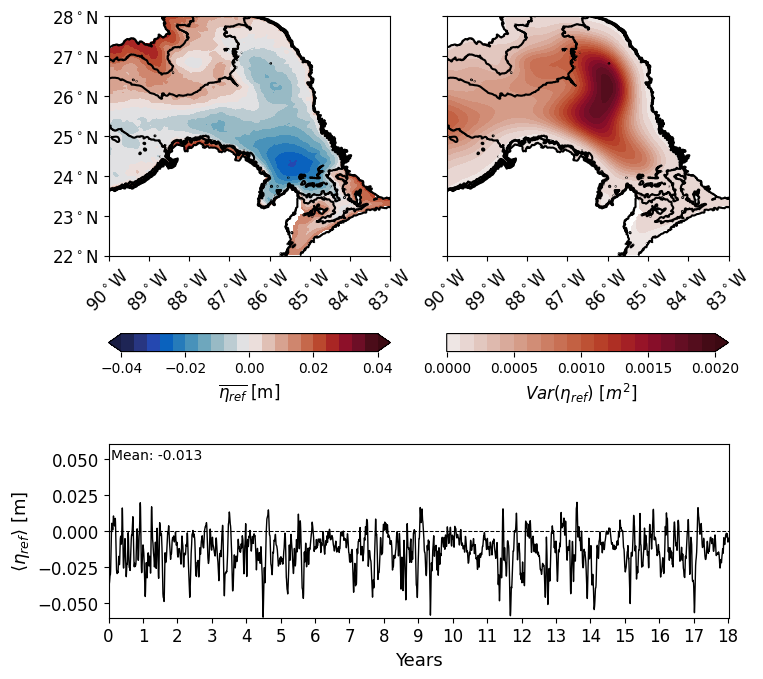

In [60]:
# Plot Mean of Eta Ref, Variance of Eta Ref, and Area-Averaged Eta Ref in DSC together

LON,LAT = np.meshgrid(lon,lat)
eref_18yr_mean = np.nanmean(eref_lp.values,axis=0)
eref_18yr_var  = np.nanvar(eref_lp.values,axis=0)

fig = plt.figure(figsize=(8,8))
gs0 = fig.add_gridspec(2,1,hspace=0.3)
gs1 = grdspc.GridSpecFromSubplotSpec(1,2,wspace=0.2,subplot_spec=gs0[0])
gs2 = grdspc.GridSpecFromSubplotSpec(3,1,subplot_spec=gs0[1])

ax = fig.add_subplot(gs1[0])
cb1 = ax.contourf(lon.values,lat.values,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,21),extend='both')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='x',rotation=45)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.set_xlim(-90,-83)
axins1 = inset_axes(ax,width="100%",height="7.5%",loc="lower center",bbox_to_anchor=(0,-.4,1,1),bbox_transform=ax.transAxes,borderpad=0)
cbar = fig.colorbar(cb1,cax=axins1,orientation='horizontal')
cbar.ax.tick_params(labelsize=10)
cbar.ax.xaxis.set_ticks([-0.04,-0.02,0.0,0.02,0.04])
cbar.set_label(label='$\overline{\eta_{ref}}$ [m]',size=12)

ax = fig.add_subplot(gs1[1])
cb2 = ax.contourf(lon.values,lat.values,eref_18yr_var,cmap=cm.cm.amp,levels=np.linspace(0,0.002,21),extend='max')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='x',rotation=45)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticklabels([''])
ax.set_yticks(lat_yticks)
ax.set_xlim(-90,-83)
axins1 = inset_axes(ax,width="100%",height="7.5%",loc="lower center",bbox_to_anchor=(0,-.4,1,1),bbox_transform=ax.transAxes,borderpad=0)
cbar = fig.colorbar(cb2,cax=axins1,orientation='horizontal')
cbar.ax.xaxis.set_ticks([0.0,0.0005,0.001,0.0015,0.002])
cbar.ax.tick_params(labelsize=10)

cbar.set_label(label='$Var(\eta_{ref})$ [$m^2$]',size=12)

ax = fig.add_subplot(gs2[1:3])
ax.plot(dsc_eref_mean,color='k',linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylabel(r'$\langle \eta_{ref} \rangle$ [m]',fontsize=13)
ax.set_xlabel('Years')

yr_ticks = [i for i in range(0,Nt,365)]
yr_labels = [i for i in range(0,19,1)]
ax.set_xticks(yr_ticks)
ax.set_xticklabels(yr_labels)
ax.set_xlabel('Years',fontsize=13)
ax.set_ylim(-0.06,0.06)
ax.set_xlim(0,Nt)
ax.hlines(0,0,Nt,linestyle='--',color='k',linewidth=0.75)
ax.text(30,0.05,s=f'Mean: {np.mean(dsc_eref_mean):.3f}')

fig.savefig(f'./Figures/18yr_MEAN_VAR_DSCEREF_{today}.svg',format='svg')


**COMPLEX EOF ANALYSIS**

In [61]:
# Do the CEOF

NOE=30

[V,EOFs,EC,my_error] = c_eof(np.transpose(lp_D),NOE)

In [62]:
max_mode = 3

mode_key = ['M1','M2','M3']

z1 = {}
zt = {}
norm_amp = {}
phase = {}

for n,mode in enumerate(mode_key):
    factor = 1 / np.max(np.abs(EOFs[:,n]))
    z1[mode] = np.abs(EOFs[:,n]) * factor
    zt[mode] = np.abs(EC[:,n]) / factor

# Reconstruct maps in lat lon space

for n,mode in enumerate(mode_key):
    shell_amp = np.full((Nlat,Nlon),np.nan)
    shell_phase = np.full((Nlat,Nlon),np.nan)

    tempvar = EOFs[:,n]
    tempcoeff = EC[:,n]
    tempvar = 180 - np.angle(tempvar) * 180 / np.pi

    shell_amp[idx[0],idx[1]] = z1[mode]
    norm_amp[mode] = shell_amp

    shell_phase[idx[0],idx[1]] = tempvar
    phase[mode] = shell_phase

phase_masked = {}

for n,mode in enumerate(mode_key):
    
    phase_masked[mode] = np.ma.masked_where(norm_amp[mode] <= 0.2,phase[mode])


In [63]:
# Percent for each mode
percentvar = np.empty(len(mode_key))

for n,_ in enumerate(mode_key):
    percentvar[n] = V[n] / np.sum(V)
    percentvar[n] = np.round(percentvar[n],3) * 100

plot_pervar = np.empty(NOE)

for n in range(NOE):
    plot_pervar[n] = V[n] / np.sum(V)
    plot_pervar[n] = np.round(plot_pervar[n],2) * 100

In [ ]:
plt.plot(np.linspace(1,NOE,NOE),plot_pervar,marker='o',linestyle='none',markersize=10,markerfacecolor='blue',markeredgecolor='black')
plt.xlabel('Mode',fontsize=16)
plt.ylabel('$\%$ Variance',fontsize=16)
#plt.title('Modes of Deep Mesoscale Eddies \nIn the Eastern Gulf',fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)

plt.text(2,plot_pervar[0]-0.75,f'Mode 1: {plot_pervar[0]}$\%$',fontsize=12)
plt.text(3,plot_pervar[1]-0.75,f'Mode 2: {plot_pervar[1]}$\%$',fontsize=12)
plt.text(4,plot_pervar[2]-0.75,f'Mode 3: {plot_pervar[2]}$\%$',fontsize=12)

#plt.savefig(f'./Figures/CEOF_Stuff/All_Modes_{today}.svg',format='svg')

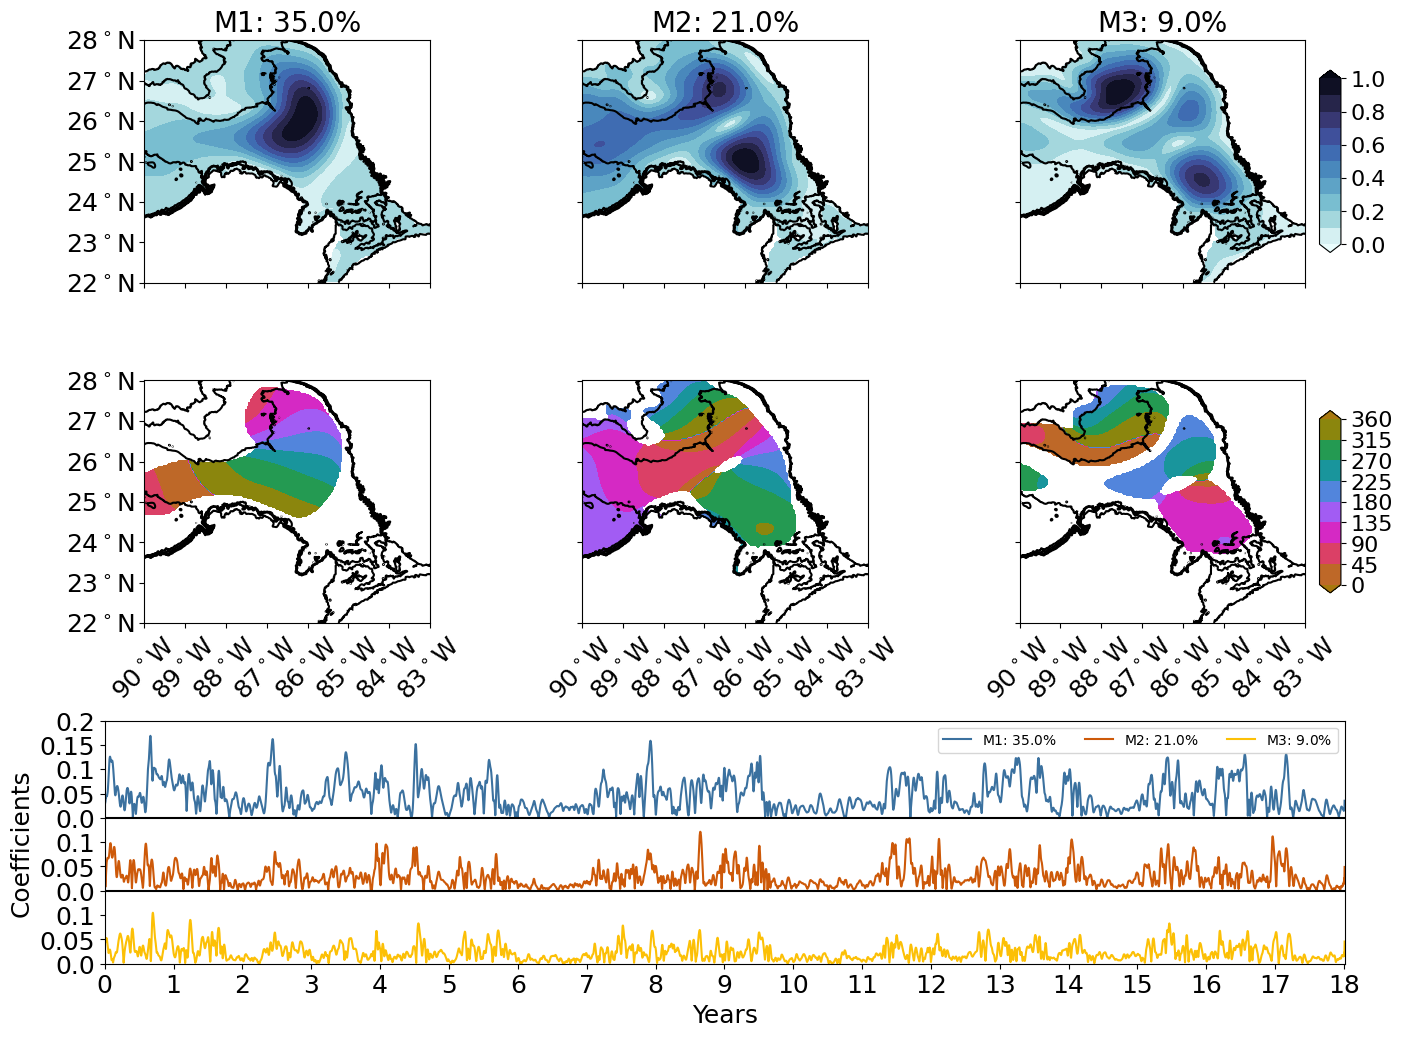

In [64]:
#-------------------------------------------------- PLOT AMP + PHASE + COEFFS


num_modes = 3

fig = plt.figure(figsize=(16,12))
gs0 = fig.add_gridspec(num_modes,1,hspace=0.4)
gs1 = grdspc.GridSpecFromSubplotSpec(1,num_modes,subplot_spec=gs0[0])
gs2 = grdspc.GridSpecFromSubplotSpec(1,num_modes,subplot_spec=gs0[1])
gs3 = grdspc.GridSpecFromSubplotSpec(1,1,subplot_spec=gs0[2])

for col in range(num_modes):
    ax = fig.add_subplot(gs1[col])

    cb1 = ax.contourf(lon,lat,norm_amp[mode_key[col]],cmap=cm.cm.ice_r,levels=np.linspace(0,1.0,11),extend='both')
    ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
    ax.set_aspect(np.cos(ymid))
    if col == 0:
        #ax.set_ylabel('Latitude',fontsize=14)
        ax.set_yticks(lat_yticks)
        ax.set_yticklabels(lat_yticklbls)
    else:
        ax.set_yticklabels([''])
    if col == num_modes-1:
        axins1 = inset_axes(ax,width="7.5%",height="75%",loc="center left",bbox_to_anchor=(1.05,0,1,1),bbox_transform=ax.transAxes,borderpad=0)
        cbar = fig.colorbar(cb1,cax=axins1)
        cbar.ax.tick_params(labelsize=16)
    ax.tick_params(axis='both',which='major',labelsize=18)
    ax.set_xticklabels([''])
    ax.set_xticks(lon_xticks)
    ax.set_xlim(-90,-83)
    ax.set_title(f'{mode_key[col]}: {plot_pervar[col]}$\%$',fontsize=20)


       

for col in range(num_modes):
    ax = fig.add_subplot(gs2[col])
    cb2 = ax.contourf(lon,lat,phase_masked[mode_key[col]],cmap=cm.cm.phase,levels=np.linspace(0,360,9),extend='both')
    ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
    ax.set_aspect(np.cos(ymid))
    #ax.set_xlabel('Longitude',fontsize=14)
    if col == 0:
        #ax.set_ylabel('Latitude',fontsize=14)
        ax.set_yticks(lat_yticks)
        ax.set_yticklabels(lat_yticklbls)
    else:
        ax.set_yticklabels([''])
    ax.set_xticklabels(lon_xticklbls)
    ax.set_xticks(lon_xticks)
    ax.tick_params(axis='x',which='major',rotation=45)
    ax.set_xlim(-90,-83)
    if col == num_modes-1:
        axins1 = inset_axes(ax,width="7.5%",height="75%",loc="center left",bbox_to_anchor=(1.05,0,1,1),bbox_transform=ax.transAxes,borderpad=0)
        cbar = fig.colorbar(cb2,cax=axins1)
        cbar.ax.tick_params(labelsize=16)
    ax.tick_params(axis='both',which='major',labelsize=18)
mode_colors = ['xkcd:muted blue','xkcd:rusty orange','xkcd:marigold']


ax = fig.add_subplot(gs3[0])

n_offset = [0.3, 0.15, 0.0]
for n,mode in enumerate(mode_key):
    if n<3:
        ax.plot(zt[mode]+n_offset[n],color=mode_colors[n],label=f'{mode}: {plot_pervar[n]}$\%$')
ax.set_xlim(0,Nt)
ax.set_ylim(0,0.5)

yr_ticks = [i for i in range(0,Nt,365)]
yr_labels = [i for i in range(0,19,1)]

ax.set_xticks(yr_ticks)
ax.set_xticklabels(yr_labels)
ax.set_yticks([0.0,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5])
ax.set_yticklabels([0.0,0.05,0.1,0.0,0.05,0.1,0.0,0.05,0.1,0.15,0.2])
ax.hlines([0.15,0.3],0,Nt,colors='black',linestyles='-')
ax.set_xlabel('Years',fontsize=18)
ax.set_ylabel('Coefficients',fontsize=18)
ax.tick_params(axis='both',which='major',labelsize=18)
ax.legend(ncols=4,loc='best')


#plt.savefig(f'./Figures/CEOF_Stuff/BP_{filtThi}to{filtTlo}_Amp_Phase_{today}.svg',format='svg')
plt.savefig(f'./Figures/CEOF_Stuff/LP_Amp_Phase_OffsetCoeffs_{today}.svg',format='svg')


In [65]:
# Conditionally average the modes 
# Find the time periods where each Mode peaks 

days = np.arange(Nt)

cond_avg = {}

for n,mode in enumerate(mode_key):
    cond_avg[mode] = {}
    cond_avg[mode]['ts'] = zt[mode] # coefficient time-series
    cond_avg[mode]['mean'] = np.mean(zt[mode]) # mean of the coefficient time-series
    cond_avg[mode]['std'] = np.std(zt[mode]) # standard dev. of the coefficient time-series
    th_mask = (zt[mode] >= (cond_avg[mode]['mean'] + cond_avg[mode]['std'] )) # make a mask where the time-series is greater than the mean plus one standard deviation
    idx_th = np.where(th_mask) # indices of the mask
    cond_avg[mode]['th'] = days[idx_th] # recorded as the threshold days
    cond_avg[mode]['length'] = LC['length'][idx_th] # LC length only using the days that meet the threshold
    cond_avg[mode]['north'] = LC['north'][idx_th] # LC northern extension only using the days that meet the threshold
    cond_avg[mode]['eref'] = eref.values[idx_th,:,:] # Eta Ref values only using the days that meet the threshold

    # now we will use the normalized time-series
    cond_avg[mode]['ts_norm'] = zt[mode] / np.std(zt[mode]) # normalized coefficient time-series using standard dev.
    th_mask = (cond_avg[mode]['ts_norm'] >= (np.mean(cond_avg[mode]['ts_norm']) + np.std(cond_avg[mode]['ts_norm']) ))
    idx_th = np.where(th_mask) 
    cond_avg[mode]['th_norm'] = days[idx_th]
    cond_avg[mode]['length_norm'] = LC['length'][idx_th] # LC length only using the days that meet the threshold
    cond_avg[mode]['north_norm'] = LC['north'][idx_th] # LC northern extension only using the days that meet the threshold
    cond_avg[mode]['eref_norm'] = eref.values[idx_th,:,:] # Eta Ref values only using the days that meet the threshold



In [66]:
# now we need the indices for the time-series chunks
# initialize
for mode in mode_key:
    keep_me = []
    keep_me_me = []

    for n in range(len(cond_avg[mode]['th'])-1):
        pt_a = cond_avg[mode]['th'][n+1]
        pt_b = cond_avg[mode]['th'][n]

        diff_ab = pt_a - pt_b

        if diff_ab != 1:
            keep_me.append(n + 1)

    cond_avg[mode]['idx']  = np.array(keep_me)

    for n in range(len(cond_avg[mode]['th_norm'])-1):
        pt_a = cond_avg[mode]['th_norm'][n+1]
        pt_b = cond_avg[mode]['th_norm'][n]

        diff_ab = pt_a - pt_b

        if diff_ab != 1:
            keep_me_me.append(n + 1)

    cond_avg[mode]['idx_norm'] = np.array(keep_me_me)

In [67]:
# Find LC separation times not counting detachments


sep_pt_400 = []

for n in range(Nt-1):
    pt1 = LC['length'][n]
    pt2 = LC['length'][n+1]

    pt_diff = pt1 - pt2

    if pt_diff >= 200:
        j = 1
        while j <= 40:
            pt_diff_test = pt1 - LC['length'][n+j+1]
            if pt_diff_test <= 400:
                break
            else:
                j += 1
                continue

        if j > 40:
            sep_pt_400.append(n)
            

when_separation = np.array(sep_pt_400)

# Now find every detachment/separation

sep_pt_det = []

for n in range(Nt-1):
    pt1 = LC['length'][n]
    pt2 = LC['length'][n+1]

    pt_diff = pt1 - pt2

    if pt_diff >= 200:
        
        sep_pt_det.append(n)
            

when_any_event = np.array(sep_pt_det)

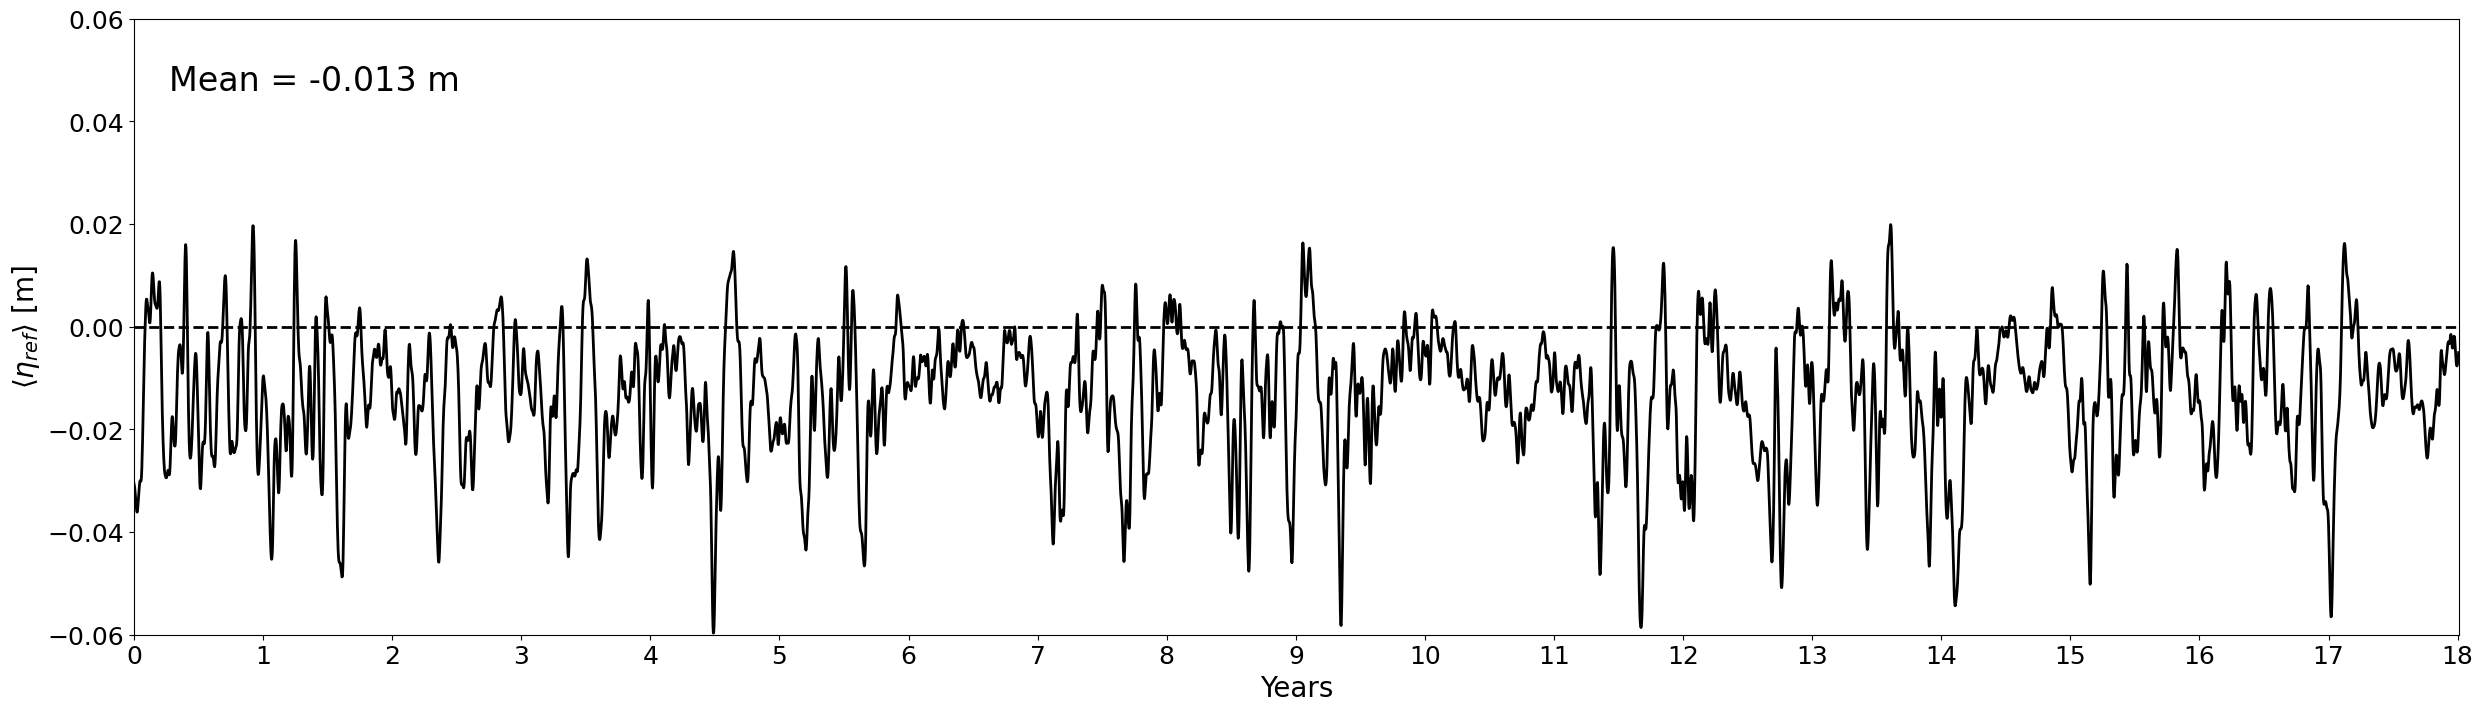

In [68]:
# Plot the LC Length with bars for the peak times of each coefficient

this_rows = 1

#fig = plt.figure(figsize=(30,5*this_rows))
fig = plt.figure(figsize=(30,8))
gs = grdspc.GridSpec(this_rows,1)

test_ = np.cumsum(LC['length']-np.mean(LC['length']))

# Plotting colors
color_box = ['xkcd:muted blue','xkcd:rusty orange','xkcd:marigold']

for n in range(this_rows):
    ax = fig.add_subplot(gs[n])

    if n == 1:
        plot_me = LC['length']
        ylim_min = 250
        ylim_max = 2500
        where_box = np.array((ylim_max-150,ylim_max-300,ylim_max-450))
        my_ylabel = 'LC Length [km]'
        rec_height = 150
        m1_txt = np.array((250,2375))
        m2_txt = np.array((250,2225))
        m3_txt = np.array((250,2075))
    elif n == 1:
        plot_me = LC['north']
        ylim_min = 23
        ylim_max = 33
        where_box = np.array((32.25,31.5,30.75))
        my_ylabel = 'LC North Ext [$^\circ$N]'
        rec_height = 0.7
        m1_txt = np.array((250,32.4))
        m2_txt = np.array((250,31.7))
        m3_txt = np.array((250,31.0))
    elif n == 3:
        plot_me = LC['west']
        ylim_min = 84.5
        ylim_max = 91.75
        where_box = np.array((91.25,90.75,90.25))
        my_ylabel = 'LC West Ext [$^\circ$W]'
        rec_height = 0.5
        m1_txt = np.array((250,91.35))
        m2_txt = np.array((250,90.85))
        m3_txt = np.array((250,90.35))
    elif n == 0:
        plot_me = dsc_eref_mean.values
        ylim_min = -0.06
        ylim_max = 0.06
        where_box = np.array((0.052,0.044,0.036))
        my_ylabel = r'$\langle \eta_{ref}\rangle$ [m]' #'$\eta_{ref}$ in DSC [m]'
        rec_height = 0.008
        m1_txt = np.array((250,0.054))
        m2_txt = np.array((250,0.046))
        m3_txt = np.array((250,0.038))
    



    ax.plot(days,plot_me,color='k',linewidth=2)
    #ax.hlines(np.mean(plot_me),xmin=0,xmax=Nt,colors='k',linestyles='--',)
    ax.hlines(0,xmin=0,xmax=Nt,colors='k',linestyles='--',linewidths=2)
    ax.set_ylim(ylim_min, ylim_max)

    ax.set_xticks(yr_ticks)
    ax.set_xticklabels([])
    ax.set_ylabel(my_ylabel,fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=18)

    for k,rec_mode in enumerate(mode_key):
        here_box = where_box[k]
        for i in range(len(cond_avg[rec_mode]['idx'])-1):

            if i == 0:
                pt1 = cond_avg[rec_mode]['th'][0]
                pt2 = cond_avg[rec_mode]['th'][cond_avg[rec_mode]['idx'][i]-1]
                rec_width = pt2-pt1

            else:
                pt1 = cond_avg[rec_mode]['th'][cond_avg[rec_mode]['idx'][i-1]]
                pt2 = cond_avg[rec_mode]['th'][cond_avg[rec_mode]['idx'][i]-1]
                rec_width = pt2-pt1

    #        ax.add_patch(Rectangle((pt1,here_box),width=rec_width,height=rec_height,color=color_box[k]))

    #for nn in range(len(when_separation)):
    #    ax.vlines(when_separation[nn],-100,3000,color='xkcd:electric purple')
    #    ax.vlines([when_separation[nn]-15,when_separation[nn]+15],-100,3000,color='xkcd:kelly green',linestyles='--')
    ax.set_xlim(0,Nt)

    ax.text(100,m2_txt[1],f'Mean = {np.round(np.mean(plot_me),3)} m',fontsize=24)
    #ax.text(Nt-m1_txt[0],m1_txt[1],'Mode 1',fontsize=16)
    #ax.text(Nt-m2_txt[0],m2_txt[1],'Mode 2',fontsize=16)
    #ax.text(Nt-m3_txt[0],m3_txt[1],'Mode 3',fontsize=16)

    if n == this_rows-1:
        yr_ticks = [i for i in range(0,Nt,365)]
        yr_labels = [i for i in range(0,19,1)]

        ax.set_xticks(yr_ticks)
        ax.set_xticklabels(yr_labels)
        ax.set_xlabel('Years',fontsize=20)

#plt.savefig(f'./Figures/CEOF_Stuff/DSCEtaRef_{today}.svg',format='svg')
#plt.savefig(f'./Figures/CEOF_Stuff/LCLength_LCNorth_{today}.svg',format='svg')

In [ ]:
# Plot the LC Length with bars for the peak times of each coefficient

this_rows = 2

fig = plt.figure(figsize=(30,5*this_rows))
gs = grdspc.GridSpec(this_rows,1)

test_ = np.cumsum(LC['length']-np.mean(LC['length']))

# Plotting colors
color_box = ['xkcd:muted blue','xkcd:rusty orange','xkcd:marigold']

for n in range(this_rows):
    ax = fig.add_subplot(gs[n])

    if n == 0:
        plot_me = LC['length']
        ylim_min = 250
        ylim_max = 2500
        where_box = np.array((ylim_max-150,ylim_max-300,ylim_max-450))
        my_ylabel = 'LC Length [km]'
        rec_height = 150
        m1_txt = np.array((250,2375))
        m2_txt = np.array((250,2225))
        m3_txt = np.array((250,2075))
    elif n == 4:
        plot_me = LC['north']
        ylim_min = 23
        ylim_max = 33
        where_box = np.array((32.25,31.5,30.75))
        my_ylabel = 'LC North Ext [$^\circ$N]'
        rec_height = 0.7
        m1_txt = np.array((250,32.4))
        m2_txt = np.array((250,31.7))
        m3_txt = np.array((250,31.0))
    elif n == 3:
        plot_me = LC['west']
        ylim_min = 84.5
        ylim_max = 91.75
        where_box = np.array((91.25,90.75,90.25))
        my_ylabel = 'LC West Ext [$^\circ$W]'
        rec_height = 0.5
        m1_txt = np.array((250,91.35))
        m2_txt = np.array((250,90.85))
        m3_txt = np.array((250,90.35))
    elif n == 1:
        plot_me = dsc_eref_mean.values
        ylim_min = -0.06
        ylim_max = 0.06
        where_box = np.array((0.052,0.044,0.036))
        my_ylabel = '$\eta_{ref}$ in DSC [m]'
        rec_height = 0.008
        m1_txt = np.array((250,0.054))
        m2_txt = np.array((250,0.046))
        m3_txt = np.array((250,0.038))
    



    ax.plot(days,plot_me,color='k',linewidth=2)
    ax.set_ylim(ylim_min, ylim_max)

    ax.set_xticks(yr_ticks)
    ax.set_xticklabels([])
    ax.set_ylabel(my_ylabel,fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)

    for k,rec_mode in enumerate(mode_key):
        here_box = where_box[k]
        for i in range(len(cond_avg[rec_mode]['idx_norm'])-1):

            if i == 0:
                pt1 = cond_avg[rec_mode]['th_norm'][0]
                pt2 = cond_avg[rec_mode]['th_norm'][cond_avg[rec_mode]['idx_norm'][i]-1]
                rec_width = pt2-pt1

            else:
                pt1 = cond_avg[rec_mode]['th_norm'][cond_avg[rec_mode]['idx_norm'][i-1]]
                pt2 = cond_avg[rec_mode]['th_norm'][cond_avg[rec_mode]['idx_norm'][i]-1]
                rec_width = pt2-pt1

            ax.add_patch(Rectangle((pt1,here_box),width=rec_width,height=rec_height,color=color_box[k]))

    for nn in range(len(when_separation)):
        ax.vlines(when_separation[nn],-100,3000,color='xkcd:electric purple')
        ax.vlines([when_separation[nn]-15,when_separation[nn]+15],-100,3000,color='xkcd:kelly green',linestyles='--')
    ax.set_xlim(0,Nt)

    ax.text(Nt-m1_txt[0],m1_txt[1],'Mode 1',fontsize=16)
    ax.text(Nt-m2_txt[0],m2_txt[1],'Mode 2',fontsize=16)
    ax.text(Nt-m3_txt[0],m3_txt[1],'Mode 3',fontsize=16)

    if n == this_rows-1:
        yr_ticks = [i for i in range(0,Nt,365)]
        yr_labels = [i for i in range(0,19,1)]

        ax.set_xticks(yr_ticks)
        ax.set_xticklabels(yr_labels)
        ax.set_xlabel('Years',fontsize=16)

#plt.savefig(f'./Figures/CEOF_Stuff/LCLength_DSCEtaRef_ModePeaks_{today}.svg',format='svg')

In [ ]:
m1_coeff_norm = zt['M1'] / np.std(zt['M1'])
m2_coeff_norm = zt['M2'] / np.std(zt['M2'])
m3_coeff_norm = zt['M3'] / np.std(zt['M3'])

fig,ax = plt.subplots(figsize=(20,5))
plt.plot(m1_coeff_norm,mode_colors[0],label=f'Mode 1: {plot_pervar[0]}$\%$')
plt.plot(m2_coeff_norm,mode_colors[1],label=f'Mode 2: {plot_pervar[1]}$\%$')
plt.plot(m3_coeff_norm,mode_colors[2],label=f'Mode 3: {plot_pervar[2]}$\%$')
plt.legend()


In [69]:
# First determine if a mode peaks during a separation (60 days prior to separation date)

# function to see if an array has any values within a range
def in_range_of(arr,low_bound,up_bound):
    return any(low_bound <= item <=up_bound for item in arr)

# function to count the number of days the mode peaks in the range
def sum_range_of(arr,low_bound,up_bound):
    return sum(low_bound <= item <=up_bound for item in arr)


mode_max_days = np.empty((len(mode_key),len(when_separation)))
# Loops through the modes to return a true or false for modes peaking during a separation event
for m,mode in enumerate(mode_key):
    max_in_separate = []
    
    for n in range(len(when_separation)):
        sep_start = when_separation[n] - 15
        sep_end = when_separation[n] + 15
        my_cond = in_range_of(cond_avg[mode]['th'],sep_start,sep_end)
        max_in_separate.append(my_cond)
        mode_max_days[m,n] = sum_range_of(cond_avg[mode]['th'],sep_start,sep_end)
        
    cond_avg[mode]['in range'] = max_in_separate

dom_mode = []
for n in range(len(when_separation)):
    this_slice = mode_max_days[:,n] 
    if sum(this_slice) == 0: 
        dom_mode.append('Skip Me')
    
    dom_mode_idx = np.where(this_slice == np.max(this_slice))
    dom_mode.append(mode_key[dom_mode_idx[0][0]])

#print(cond_avg['M1']['in range'])
#print(cond_avg['M2']['in range'])
#print(cond_avg['M3']['in range'])



### Any event

mode_max_days_any = np.empty((len(mode_key),len(when_any_event)))
# Loops through the modes to return a true or false for modes peaking during a separation event
for m,mode in enumerate(mode_key):
    max_in_separate = []
    
    for n in range(len(when_any_event)):
        sep_start = when_any_event[n] - 15
        sep_end = when_any_event[n] + 15
        my_cond = in_range_of(cond_avg[mode]['th'],sep_start,sep_end)
        max_in_separate.append(my_cond)
        mode_max_days_any[m,n] = sum_range_of(cond_avg[mode]['th'],sep_start,sep_end)
        
    cond_avg[mode]['in range'] = max_in_separate

dom_mode_any = []
for n in range(len(when_any_event)):
    this_slice = mode_max_days_any[:,n] 
    if sum(this_slice) == 0: 
        dom_mode_any.append('Skip Me')
    
    dom_mode_idx = np.where(this_slice == np.max(this_slice))
    dom_mode_any.append(mode_key[dom_mode_idx[0][0]])

In [ ]:
# LC North Extension versus DSC

eta_ref_threshold = np.mean(dsc_eref_mean)

fig,ax = plt.subplots(figsize=(12,10))

dsc_plot = dsc_eref_mean.values[when_separation+1]
lc_plot = LC['north'][when_separation+1]

for n in range(len(when_separation)):
    #if np.abs(dsc_plot[n]) >= 0.025:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='o',markeredgecolor='black',markerfacecolor='xkcd:kelly green')
    #else:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='o',markeredgecolor='black',markerfacecolor='xkcd:coral')
    
    this_mode = dom_mode[n]

    if this_mode == 'M1':
        m_color = 0
    elif this_mode == 'M2':
        m_color = 1
    elif this_mode == 'M3':
        m_color = 2
    else:
        continue
    
    ax.plot(dsc_plot[n],lc_plot[n],marker='o',markerfacecolor=mode_colors[m_color],markeredgecolor='k',markersize=8)

    #if cond_avg['M1']['in range'][n] == True:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='s',markeredgecolor=mode_colors[0],markerfacecolor='none',markersize=10)
    
    #if cond_avg['M2']['in range'][n] == True:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='s',markeredgecolor=mode_colors[1],markerfacecolor='none',markersize=14)
    
    #if cond_avg['M3']['in range'][n] == True:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='s',markeredgecolor=mode_colors[2],markerfacecolor='none',markersize=18)

#ax.hlines(25,eta_ref_threshold,-0.06,colors='k')
ax.vlines(0,24,28,colors='k',linestyles='--')
ax.add_patch(Rectangle((-0.06,24.25),width=(eta_ref_threshold - -0.06),height=0.75,color='gray',alpha=0.25))
#ax.set_xlabel('DSC Cyclone $\eta_{ref}$ Strength',fontsize=14)
ax.set_xlabel(r'$\langle\eta_{ref}\rangle$ Strength',fontsize=14)
ax.set_xlim(0.02,-0.06)
ax.set_ylim(24.25,27.5)
ax.set_ylabel('LC Northern Extension',fontsize=14)
ax.set_yticklabels(['$24.5^\circ$N','$25.0^\circ$N','$25.5^\circ$N','$26.0^\circ$N','$26.5^\circ$N','$27.0^\circ$N',])
ax.set_yticks(np.array((24.5,25,25.5,26,26.5,27)))
ax.tick_params(axis='both', which='major', labelsize=14)
#ax.set_title('LC Northern Extension and DSC Strength\nAfter Separation',fontsize=18)


ax_inset = fig.add_axes(
    [0.575,0.6,0.3,0.25]
)

for n in range(len(when_separation)):
    this_mode = dom_mode[n]

    if this_mode == 'M1':
        m_color = 0
    elif this_mode == 'M2':
        m_color = 1
    elif this_mode == 'M3':
        m_color = 2
    else:
        continue
    
    ax_inset.contour(lon,lat,ssh_demean.values[when_separation[n]+1,:,:],[0.17],linewidths=2,colors=mode_colors[m_color])
ax_inset.contour(gulf_lon,gulf_lat,np.flipud(img),[-3500,-3000,-2500,-2000],colors='k',linestyles='-')
#fig.colorbar(cb,location='bottom',shrink=0.75,label='Elevation [m]')
ax_inset.set_aspect(np.cos(ymid))
ax_inset.set_xlabel('Longitude',fontsize=14)
ax_inset.set_xticks(np.array((-90,-88,-86,-84,-82)))
ax_inset.set_xticklabels(['$90^\circ$W','$88^\circ$W','$86^\circ$W','$84^\circ$W','$82^\circ$W'])
ax_inset.set_ylabel('Latitude',fontsize=14)
ax_inset.set_yticklabels(lat_yticklbls)



#plt.savefig(f'./Figures/North_vs_CycloneStrength_wider_{today}.svg',format='svg')


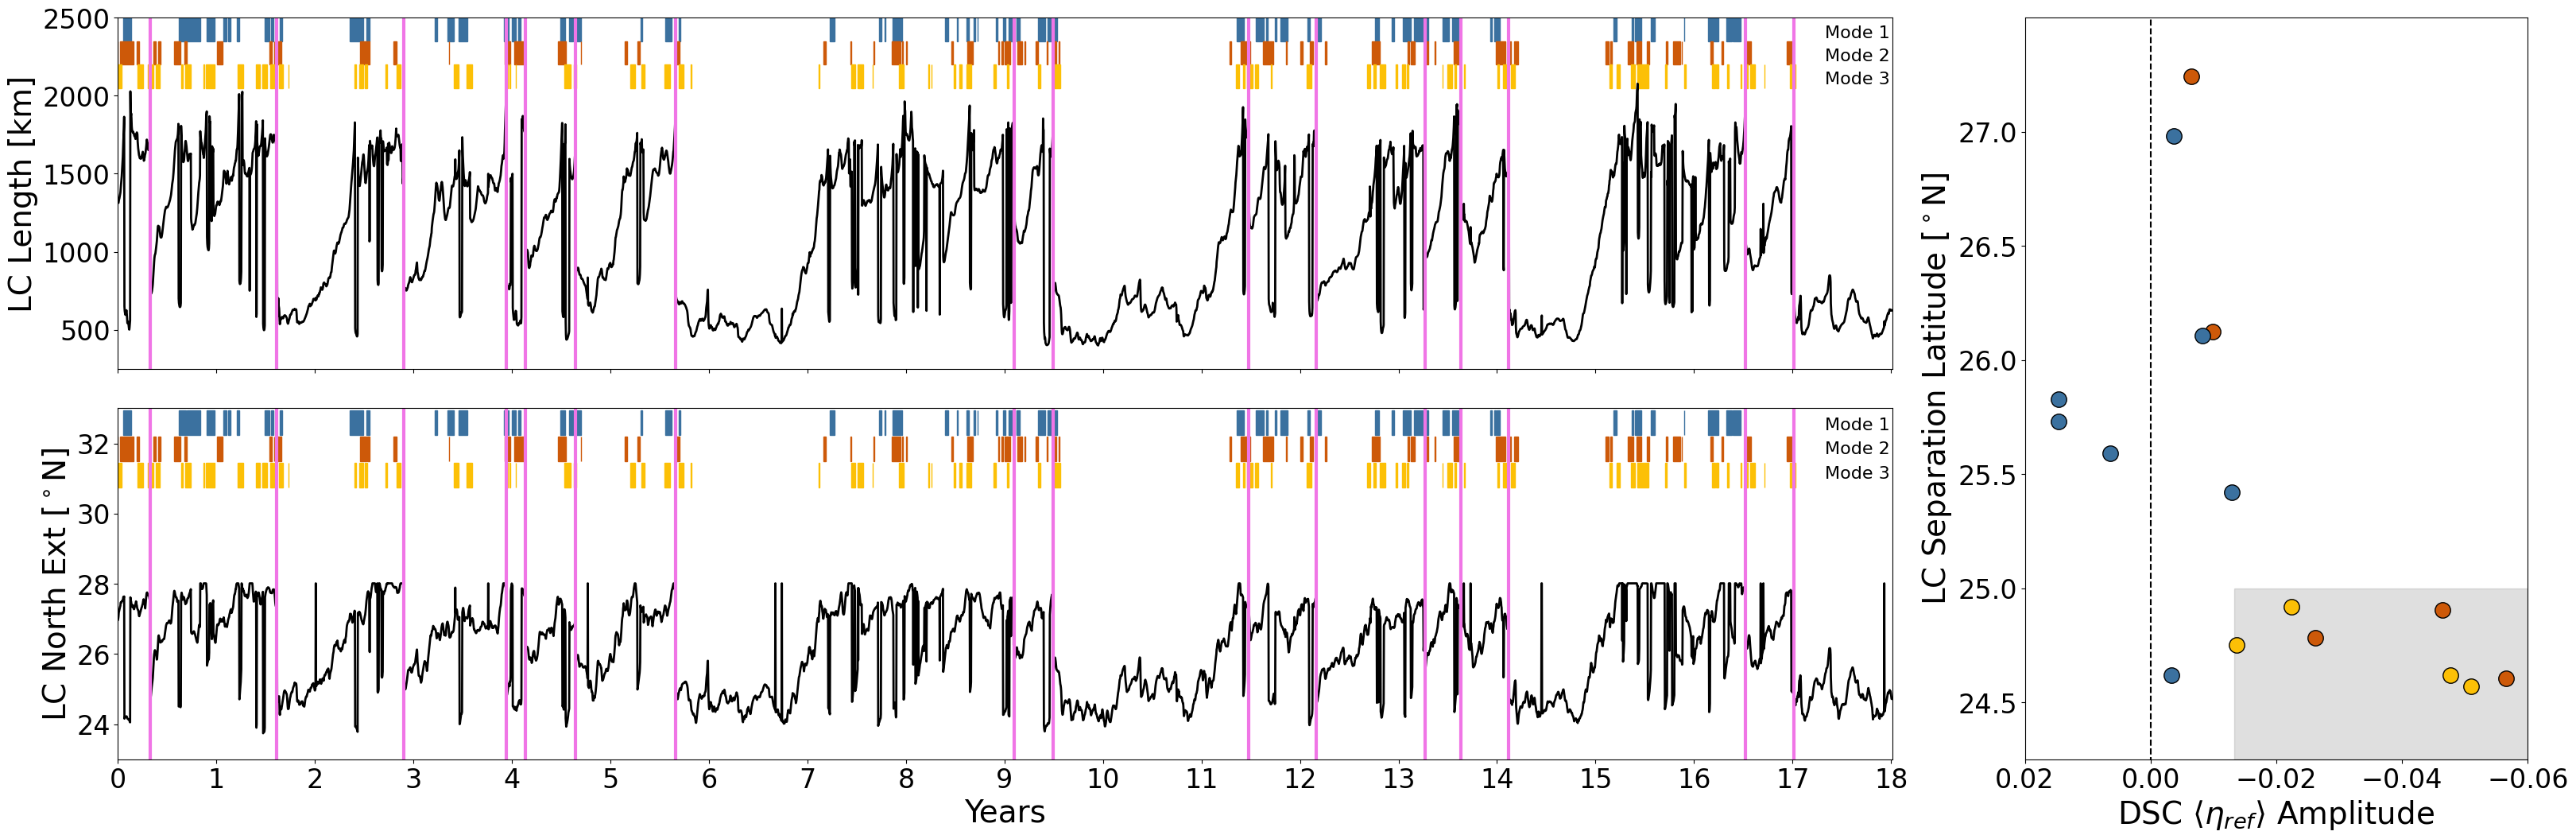

In [78]:
# Combine the LC North Ext vs Eta ref Strength and the time-series with mode peaks

# Plot the LC Length with bars for the peak times of each coefficient


fig = plt.figure(figsize=(40,20))
gs = grdspc.GridSpec(2,5)
gs0 = grdspc.GridSpecFromSubplotSpec(2,1,gs[0:1,0:3])
gs1 = grdspc.GridSpecFromSubplotSpec(1,1,gs[0:1,3:4])
#gs1 = grdspc.GridSpecFromSubplotSpec(1,3,gs0[1])

for n in range(2):
    ax = fig.add_subplot(gs0[n])

    if n == 0:
        plot_me = LC['length']
        ylim_min = 250
        ylim_max = 2500
        where_box = np.array((ylim_max-150,ylim_max-300,ylim_max-450))
        my_ylabel = 'LC Length [km]'
        rec_height = 150
        m1_txt = np.array((250,2375))
        m2_txt = np.array((250,2225))
        m3_txt = np.array((250,2075))
    elif n == 1:
        plot_me = LC['north']
        ylim_min = 23
        ylim_max = 33
        where_box = np.array((32.25,31.5,30.75))
        my_ylabel = 'LC North Ext [$^\circ$N]'
        rec_height = 0.7
        m1_txt = np.array((250,32.4))
        m2_txt = np.array((250,31.7))
        m3_txt = np.array((250,31.0))
    
    ax.plot(days,plot_me,color='k',linewidth=2)
    ax.set_ylim(ylim_min, ylim_max)

    ax.set_xticks(yr_ticks)
    ax.set_xticklabels([])
    ax.set_ylabel(my_ylabel,fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=24)

    for k,rec_mode in enumerate(mode_key):
        here_box = where_box[k]
        for i in range(len(cond_avg[rec_mode]['idx_norm'])-1):

            if i == 0:
                pt1 = cond_avg[rec_mode]['th_norm'][0]
                pt2 = cond_avg[rec_mode]['th_norm'][cond_avg[rec_mode]['idx_norm'][i]-1]
                rec_width = pt2-pt1

            else:
                pt1 = cond_avg[rec_mode]['th_norm'][cond_avg[rec_mode]['idx_norm'][i-1]]
                pt2 = cond_avg[rec_mode]['th_norm'][cond_avg[rec_mode]['idx_norm'][i]-1]
                rec_width = pt2-pt1

            ax.add_patch(Rectangle((pt1,here_box),width=rec_width,height=rec_height,color=color_box[k]))

    for nn in range(len(when_separation)):
        ax.vlines(when_separation[nn],-100,3000,color='xkcd:purply pink',linewidth=3)
        #ax.vlines([when_separation[nn]-15,when_separation[nn]+15],-100,3000,color='xkcd:kelly green',linestyles='--',linewidth=2)
    ax.set_xlim(0,Nt)

    ax.text(Nt-m1_txt[0],m1_txt[1],'Mode 1',fontsize=16)
    ax.text(Nt-m2_txt[0],m2_txt[1],'Mode 2',fontsize=16)
    ax.text(Nt-m3_txt[0],m3_txt[1],'Mode 3',fontsize=16)

    if n == 1:
        yr_ticks = [i for i in range(0,Nt,365)]
        yr_labels = [i for i in range(0,19,1)]

        ax.set_xticks(yr_ticks)
        ax.set_xticklabels(yr_labels)
        ax.set_xlabel('Years',fontsize=28)

# -------------------------------------------------------------- Does the LC vs Eta Ref strength plot

# LC North Extension versus DSC

eta_ref_threshold = np.mean(dsc_eref_mean)

ax = fig.add_subplot(gs1[0])

dsc_plot = dsc_eref_mean.values[when_separation+1]
lc_plot = LC['north'][when_separation+1]

for n in range(len(when_separation)):
    
    this_mode = dom_mode[n]

    if this_mode == 'M1':
        m_color = 0
    elif this_mode == 'M2':
        m_color = 1
    elif this_mode == 'M3':
        m_color = 2
    else:
        continue
    
    ax.plot(dsc_plot[n],lc_plot[n],marker='o',markerfacecolor=mode_colors[m_color],markeredgecolor='k',markersize=14)

    

#ax.hlines(25,eta_ref_threshold,-0.06,colors='k')
ax.vlines(0,24,28,colors='k',linestyles='--')
ax.add_patch(Rectangle((-0.06,24.25),width=(eta_ref_threshold - -0.06),height=0.75,color='gray',alpha=0.25))
#ax.set_xlabel('DSC Cyclone $\eta_{ref}$ Strength',fontsize=14)
ax.set_xlabel(r'DSC $\langle\eta_{ref}\rangle$ Amplitude',fontsize=28)
ax.set_xlim(0.02,-0.06)
ax.set_ylim(24.25,27.5)
ax.set_ylabel('LC Separation Latitude [$^\circ$N]',fontsize=28)
#ax.set_yticklabels(['$24.5^\circ$N','$25.0^\circ$N','$25.5^\circ$N','$26.0^\circ$N','$26.5^\circ$N','$27.0^\circ$N',])
ax.set_yticklabels(['24.5','25.0','25.5','26.0','26.5','27.0',])
ax.set_yticks(np.array((24.5,25,25.5,26,26.5,27)))
ax.tick_params(axis='both', which='major', labelsize=24)
#ax.set_title('LC Northern Extension and DSC Strength\nAfter Separation',fontsize=18)




plt.tight_layout()

plt.savefig(f'./Figures/LC_LengthExt_TimeSeries_AND_Ext_vs_CycloneStrength_{today}.svg',format='svg',bbox_inches='tight')

In [ ]:
# LC North Extension versus DSC for any detachment event

eta_ref_threshold = np.mean(dsc_eref_mean)

fig,ax = plt.subplots(figsize=(12,10))

dsc_plot = dsc_eref_mean.values[when_any_event+1]
lc_plot = LC['north'][when_any_event+1]

for n in range(len(when_any_event)):
    #if np.abs(dsc_plot[n]) >= 0.025:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='o',markeredgecolor='black',markerfacecolor='xkcd:kelly green')
    #else:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='o',markeredgecolor='black',markerfacecolor='xkcd:coral')
    
    this_mode = dom_mode_any[n]

    if this_mode == 'M1':
        m_color = 0
    elif this_mode == 'M2':
        m_color = 1
    elif this_mode == 'M3':
        m_color = 2
    else:
        continue
    
    ax.plot(dsc_plot[n],lc_plot[n],marker='o',markerfacecolor=mode_colors[m_color],markeredgecolor='k',markersize=8)

    #if cond_avg['M1']['in range'][n] == True:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='s',markeredgecolor=mode_colors[0],markerfacecolor='none',markersize=10)
    
    #if cond_avg['M2']['in range'][n] == True:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='s',markeredgecolor=mode_colors[1],markerfacecolor='none',markersize=14)
    
    #if cond_avg['M3']['in range'][n] == True:
    #    ax.plot(dsc_plot[n],lc_plot[n],marker='s',markeredgecolor=mode_colors[2],markerfacecolor='none',markersize=18)

#ax.hlines(25,eta_ref_threshold,-0.06,colors='k')
#ax.vlines(eta_ref_threshold,24,25,colors='k')
ax.add_patch(Rectangle((-0.06,24.25),width=(eta_ref_threshold - -0.06),height=0.75,color='gray',alpha=0.25))
ax.set_xlabel('DSC Cyclone $\eta_{ref}$ Strength',fontsize=14)
ax.set_xlim(0.02,-0.06)
ax.set_ylim(22.25,27.5)
ax.set_ylabel('LC Northern Extension',fontsize=14)
ax.set_yticklabels(['$24.5^\circ$N','$25.0^\circ$N','$25.5^\circ$N','$26.0^\circ$N','$26.5^\circ$N','$27.0^\circ$N',])
ax.set_yticks(np.array((24.5,25,25.5,26,26.5,27)))
ax.tick_params(axis='both', which='major', labelsize=14)
#ax.set_title('LC Northern Extension and DSC Strength\nAfter Separation',fontsize=18)



#plt.savefig(f'./Figures/North_vs_CycloneStrength_wider_{today}.svg',format='svg')


In [ ]:
these_days = [-60,-45,-30,-15,1]

for i in range(len(when_separation)):
    check_1 = LC['north'][when_separation[i]+1]
    check_2 = dsc_eref_mean.values[when_separation[i]+1]
    
    if check_1 <= 25.0 and check_2 <= -0.02:

        plt.subplots(1,len(these_days),figsize=(40,10))
        
        for j in range(len(these_days)):

            ax = plt.subplot(1,len(these_days),j+1)

            cb1 = ax.contourf(lon,lat,eref_vals_lp[when_separation[i]+these_days[j],:,:],levels=np.linspace(-0.1,0.1,11),extend='both',cmap=cm.cm.balance)
            plt.contour(lon,lat,ssh_demean.values[when_separation[i]+these_days[j],:,:],levels=[0.17],colors='black',linewidths=2)
            cb2 = ax.contour(lon,lat,ssha[when_separation[i]+these_days[j],:,:],levels=np.linspace(-0.25,0.25,11),extend='both',cmap=cm.cm.balance) 
            ax.set_aspect(np.cos(ymid))
            ax.set_xlabel('Longitude',fontsize=18)
            
            ax.set_xlim(-90,-83)
            ax.set_xticks(lon_xticks)
            ax.set_xticklabels(lon_xticklbls)
            if j == 0:
                ax.set_ylabel('Latitude',fontsize=18)
                ax.set_yticks(lat_yticks)
                ax.set_yticklabels(lat_yticklbls)
            ax.tick_params(axis='both',which='major',labelsize=16)
            if j < len(these_days) - 1:
                ax.set_title(f'{these_days[j]}',fontsize=18)
            else:
                ax.set_title('Separation',fontsize=18)
            #if j == 0:
            #    plt.colorbar(cb1,location='bottom')
            #elif j == 2:
            #plt.colorbar(cb2,location='bottom')

        #plt.savefig(f'./Figures/UpperDeep/SouthernSeparations_TimeSeries_SSHA_EtaRef_Sep{i+1}_{today}.png',format='png',dpi=450)


In [ ]:
# Create composites of when the separation occurs below 25N

# How many separations occur south of 25N?
ii = 0
for n in range(len(when_separation)):
    check_1 = LC['north'][when_separation[n]+1]
    check_2 = dsc_eref_mean.values[when_separation[i]+1]

    if check_1 <= 25.0 and check_2 <= -0.02:
        ii += 1

# Now get the relevant times and make composites
days_before = 45
days_after = 16
days_total = days_before + days_after 

get_ts_deep = np.ma.masked_all((ii,days_total,Nlat,Nlon))
get_ts_ssh = np.ma.masked_all((ii,days_total,Nlat,Nlon))

nn = 0
for i in range(len(when_separation)):
    check_1 = LC['north'][when_separation[i]+1]
    check_2 = dsc_eref_mean.values[when_separation[i]+1]

    if check_1 <= 25.0 and check_2 <= -0.02:
        get_ts_deep[nn,:,:,:] = eref_vals_lp[(when_separation[i]-days_before):(when_separation[i]+days_after),:,:]
        get_ts_ssh[nn,:,:,:] = ssh.values[(when_separation[i]-days_before):(when_separation[i]+days_after),:,:]

south25_composite = {}
south25_composite['deep'] = np.nanmean(get_ts_deep,axis=0)
south25_composite['ssh'] = np.nanmean(get_ts_ssh,axis=0)

place_holder = np.ma.masked_all((days_total,Nlat,Nlon))
for tt in range(days_total):
    place_holder[tt,:,:] = south25_composite['ssh'][tt,:,:] - np.nanmean(south25_composite['ssh'],axis=(1,2))[tt]
south25_composite['ssh_demean'] = place_holder

south25_composite['ssha'] = south25_composite['ssh_demean'] - np.nanmean(ssh_demean.values,axis=0)

In [ ]:
these_days = [0,15,30,46,52]

fig = plt.subplots(1,len(these_days),figsize=(40,20))

for j in range(len(these_days)):

    ax = plt.subplot(1,len(these_days),j+1)
    cb1 = plt.contourf(lon,lat,south25_composite['deep'][these_days[j],:,:],levels=np.linspace(-0.1,0.1,11),extend='both',cmap=cm.cm.balance)
    plt.contour(lon,lat,south25_composite['ssh_demean'][these_days[j],:,:],levels=[0.17],colors='black',linewidths=2)
    cb2 = ax.contour(lon,lat,south25_composite['ssha'][these_days[j],:,:],np.linspace(-0.25,0.25,11),extend='both',cmap=cm.cm.balance)
    ax.set_aspect(np.cos(ymid))
    ax.set_xlabel('Longitude',fontsize=18)

    ax.set_xlim(-90,-83)
    ax.set_xticks(lon_xticks)
    ax.set_xticklabels(lon_xticklbls)
    if j == 0:
        ax.set_ylabel('Latitude',fontsize=18)
        ax.set_yticks(lat_yticks)
        ax.set_yticklabels(lat_yticklbls)
    ax.tick_params(axis='both',which='major',labelsize=16)
    if days_before-these_days[j] > -1:
        ax.set_title(f'{days_before-these_days[j]}',fontsize=18)
    elif days_before-these_days[j] < -1:
        ax.set_title(f'{these_days[j] - (days_before)}',fontsize=18)
    else:
        ax.set_title('Separation',fontsize=18)
#if j == 0:
#    plt.colorbar(cb1,location='bottom')
#elif j == 2:
#plt.colorbar(cb2,location='bottom')

#plt.savefig(f'./Figures/UpperDeep/SouthernSeparations_Composite_SSHA_EtaRef_{today}.png',format='png',dpi=450)




**Cross Correlations of Stuff**

In [ ]:
# Cross correlation between the mode coefficients and the DSC eta ref time-series

# Demean the DSC eta ref values
dsc_eref_demean = dsc_eref_mean.values - np.mean(dsc_eref_mean.values)

# Find Hilbert Transform of the eta ref signal in the DSC
# Use the envelope for cross correlation between DSC envelope and mode coefficients

dsc_eref_hat = sp.signal.hilbert(dsc_eref_demean)
dsc_hilb = dsc_eref_demean + dsc_eref_hat
dsc_env = np.abs(dsc_hilb)

corr_max = np.empty(len(mode_key))
corr_min = np.empty(len(mode_key))
corr_lag = np.empty(len(mode_key))
this_minmax = np.empty(len(mode_key))

for n,mode in enumerate(mode_key):
    
    # Demean the mode coefficients
    mode_coeff_demean = np.real(EC[:,n]) #cond_avg[mode]['ts'] - cond_avg[mode]['mean']

    # First get the correlation, then the lag
    cond_avg[mode]['corr'] = sp.signal.correlate(dsc_env,mode_coeff_demean,mode='full',method='auto')
    cond_avg[mode]['corr'] /= np.max(np.abs(cond_avg[mode]['corr']))
    cond_avg[mode]['lag']  = sp.signal.correlation_lags(len(mode_coeff_demean),len(dsc_env))

    corr_max[n] = np.max(cond_avg[mode]['corr'])
    corr_min[n] = np.min(cond_avg[mode]['corr'])
    print(corr_max[n],corr_min[n])
    if np.abs(corr_max[n]) > np.abs(corr_min[n]):
        this_idx = np.where(cond_avg[mode]['corr'] == corr_max[n])
        this_minmax[n] = corr_max[n]
        print(corr_max[n])
    elif np.abs(corr_min[n]) > np.abs(corr_max[n]):
        this_idx = np.where(cond_avg[mode]['corr'] == corr_min[n])
        this_minmax[n] = corr_min[n]
        print(corr_min[n])
    corr_lag[n] = cond_avg[mode]['lag'][this_idx]

In [ ]:

fig = plt.figure(figsize=(20,10))

gs = grdspc.GridSpec(3,1)

for n,mode in enumerate(mode_key):
    ax = fig.add_subplot(gs[n])
    ax.plot(cond_avg[mode]['lag'],cond_avg[mode]['corr'],color=mode_colors[n],linewidth='2')
    #this_title = 'Correlation Between DSC $\eta_{ref}$'+f' \nand \nMode {n} Coefficient'
    #ax.set_title(this_title,fontsize=16)
    ax.text(corr_lag[n],this_minmax[n],f'Lag = {corr_lag[n]} Days',fontsize=12)
    ax.set_ylabel('Correlation',fontsize=12)
    if n == 2:
        ax.set_xlabel('Lag',fontsize=12)
    else:
        ax.set_xticklabels([])
    ax.set_xlim(-100,100)
    #ax.set_ylim(-1,1)


#fig.suptitle('Correlation between $\eta_{ref}$ and Mode Coefficients',fontsize=18)

In [ ]:
LC_length_demean = LC['length']-np.mean(LC['length'])
temp = (dsc_eref_mean.values)
dsc_eref_csum_demean = temp - np.mean(temp)

upper_deep_corr = sp.signal.correlate(dsc_eref_csum_demean,LC_length_demean,mode='full',method='auto')
upper_deep_corr /= np.max(upper_deep_corr)
upper_deep_lags = sp.signal.correlation_lags(len(mode_coeff_demean),len(dsc_eref_csum_demean))

ud_corr_lag = np.max(np.abs(upper_deep_corr))
ud_corr_lag_loc = np.where(np.abs(upper_deep_corr) == ud_corr_lag)
ud_corr_idx = upper_deep_lags[ud_corr_lag_loc]

fig,ax = plt.subplots(figsize=(20,5))
ax.plot(upper_deep_lags,upper_deep_corr,color='k',linewidth=2)
ax.text(ud_corr_idx+10,ud_corr_lag,f'Lag = {ud_corr_idx} Days',fontsize=12)
ax.set_xlabel('Lag',fontsize=14)
ax.set_ylabel('Correlation',fontsize=14)
ax.set_title('Correlation between Cumulative Sum of $\eta_{ref}$ and LC Length',fontsize=18)


**Find the Spectra at Hot Spots**

In [ ]:
# First get the indices for my points below

#myLats = np.array([26, 26.75, 25, 26.75,24.5,25.5],dtype=float)
#myLons = np.array([-86, -86.7, -86, -87.5, -85.5,-89],dtype=float)

myLats = np.array([24.5,25,26, 26.75,  26.75,25.5],dtype=float)
myLons = np.array([-85.5,-86,-86, -86.7,  -87.5, -89],dtype=float)

lat_idx = np.argmin(np.abs(lat.values[:, None] - myLats[None, :]), axis=0)
lon_idx = np.argmin(np.abs(lon.values[:, None] - myLons[None, :]), axis=0)

N_pts = len(myLats)

from scipy.signal import welch

myseg = 256

plot_f = np.zeros((129,N_pts))
plot_psd = np.zeros((129,N_pts))

for pts in range(N_pts):
    myvals = eref_vals[:,lat_idx[pts],lon_idx[pts]]

    f,psd = welch(myvals,1,nperseg=256,noverlap=128)

    plot_f[:,pts] = f
    plot_psd[:,pts] = f*psd


# Find PSD of DSC eta ref as well
dsc_f,dsc_psd = welch(dsc_eref_mean,1,nperseg=myseg,noverlap=myseg/2)
dsc_psd = dsc_f*dsc_psd

In [ ]:
# Spectrum of Mode Coeffs

from scipy.signal import welch
myseg = 384

pcoeff_f = np.zeros((int(myseg/2+1),max_mode))
pcoeff_psd = np.zeros((int(myseg/2+1),max_mode))

for n,mode in enumerate(mode_key):
    myvals = zt[mode]

    f,psd = welch(myvals,1,nperseg=myseg,noverlap=int(myseg/2))

    pcoeff_f[:,n] = f
    pcoeff_psd[:,n] = f*psd


fig,ax = plt.subplots(figsize=(10,10))

mode_colors = ['xkcd:muted blue','xkcd:rusty orange','xkcd:marigold']
bp_lims = np.array((1/150,1/60,1/30,1/10),dtype=float)
bp_lims_days = ['150 Days','60 Days','30 Days','10 Days']

for n in range(max_mode):
    ax.semilogx(pcoeff_f[:,n],pcoeff_psd[:,n],color=mode_colors[n],label=f'{mode_key[n]}')
ax.set_ylabel('$\omega\cdot$PSD',fontsize=14)
ax.set_xlabel('$\omega$ [days$^{-1}$]',fontsize=14)
ax.vlines([1/150,1/60,1/30,1/10],0,0.00035,colors='black',linestyles='--')
for i in range(len(bp_lims)):
    ax.text(bp_lims[i],0.000340,bp_lims_days[i],fontsize=12)
ax.set_ylim(0,0.00035)
ax.tick_params(axis='both',which='major',labelsize=14)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


In [ ]:
# Plot the DSC Spectrum
bp_lims = np.array((1/150,1/60,1/30,1/10),dtype=float)
bp_lims_days = ['150 Days','60 Days','30 Days','10 Days']

fig, ax_main = plt.subplots(figsize=(10,5))
ax_main.semilogx(dsc_f,dsc_psd)
ax_main.set_ylabel('$\omega\cdot$PSD',fontsize=14)
ax_main.set_xlabel('$\omega$ [days$^{-1}$]',fontsize=14)
ax_main.vlines([1/150,1/60,1/30,1/10],0,1,colors='black',linestyles='--')
for i in range(len(bp_lims)):
    ax_main.text(bp_lims[i],0.0000845,bp_lims_days[i],fontsize=12)
ax_main.set_ylim(0,0.00009)
ax_main.tick_params(axis='both',which='major',labelsize=14)
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

In [ ]:
# Plot of spectra based on full eta ref

fig, ax_main = plt.subplots(figsize=(15,10))

spectra_colors = ["#b80000","#ca6200","#04a804","#00B7C4","#0c00b8","#8a009c"]
spectra_shapes = ["P","D","^","o","s","*"]
bp_lims = np.array((1/150,1/60,1/30,1/10),dtype=float)
bp_lims_days = ['150 Days','60 Days','30 Days','10 Days']


for pts in range(N_pts):
    idx_max_psd = np.array(np.where(plot_psd[:,pts] == np.max(plot_psd[:,pts])))
    ax_main.semilogx(plot_f[:,pts],plot_psd[:,pts],color=spectra_colors[pts])#,label=f'Lat: {myLats[pts]} Lon: {myLons[pts]}')
    ax_main.semilogx(plot_f[idx_max_psd,pts],np.max(plot_psd[:,pts])+0.00005,color=spectra_colors[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='k',markersize=11,label=f'Lat: {myLats[pts]} Lon: {myLons[pts]}')
ax_main.legend(ncols=1,loc='upper right')
ax_main.set_ylabel(r'Variance $\times 10^{-3}$ [m$^2$]',fontsize=16)
ax_main.set_xlabel('$f$ [days$^{-1}$]',fontsize=16)
ax_main.vlines([1/150,1/60,1/30,1/10],0,1,colors='black',linestyles='--')
for i in range(len(bp_lims)):
    ax_main.text(bp_lims[i],0.00145,bp_lims_days[i],fontsize=16)
ax_main.set_ylim(0,0.0015)
ax_main.tick_params(axis='both',which='major',labelsize=16)
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax_inset = fig.add_axes(
    [0.565,0.4,0.45,0.25]
)

cb = ax_inset.contourf(gulf_lon,gulf_lat,np.flipud(img),cmap=cm.cm.deep)
#fig.colorbar(cb,location='bottom',shrink=0.75,label='Elevation [m]')
ax_inset.set_aspect(np.cos(ymid))
ax_inset.set_xlabel('Longitude',fontsize=12)
ax_inset.set_ylabel('Latitude',fontsize=12)
ax_inset.set_xticks(lon_xticks)
ax_inset.set_xticklabels(lon_xticklbls)
ax_inset.set_yticks(lat_yticks)
ax_inset.set_yticklabels(lat_yticklbls)
ax_inset.tick_params(axis='both',which='major',labelsize=8)
ax_inset.set_xlim(-90,-83)
for pts in range(N_pts):
    ax_inset.plot(myLons[pts],myLats[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='black',linestyle='none',markersize=8)
    if pts == N_pts-1:
        ax_inset.plot(myLons[pts],myLats[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='black',linestyle='none',markersize=12)

#fig.savefig(f'./Figures/Spectrum/Eta_ref_withSymbols_RGB_{today}.svg',format='svg')

**Recreate the deep field using each of the modes at predetermined times**

In [ ]:
# 18 year mean of eta ref
eref_18yr_mean = np.nanmean(eref_vals_lp,axis=0)

for m,mode in enumerate(mode_key):
    
    # Create time-series of reconstructed modes
    arr1 = EC[:,m].reshape(-1,1)
    arr2 = EOFs[:,m].reshape(-1,1)

    arr2_tr = arr2.conj().T

    temp_recon = arr1 * arr2_tr

    temp_real = np.real(temp_recon)
    shell_recon = np.ma.zeros((Nt,Nlat,Nlon))

    for t in range(Nt):
        shell_recon[t,idx[0],idx[1]] = temp_real[t,:]
    
    mask_recon = shell_recon == 0.0
    masked_recon = np.ma.masked_array(shell_recon,mask=mask_recon)
    cond_avg[mode]['eref recon'] = masked_recon 

In [ ]:
# Now find the spectra at hot-spots for reconstructed modes

plot_f_recon = np.zeros((129,N_pts))
plot_psd_recon = np.zeros((129,N_pts))

for pts in range(N_pts):
    if pts == 0:
        mode = 'M1'
    elif pts == 1 or pts == 2:
        mode = 'M2'
    else:
        mode = 'M3'
        
    myvals = cond_avg[mode]['eref recon'][:,lat_idx[pts],lon_idx[pts]]

    f,psd = welch(myvals,1,nperseg=256,noverlap=128)

    plot_f_recon[:,pts] = f
    plot_psd_recon[:,pts] = f*psd


In [ ]:
# Plot of spectra based on full eta ref

fig, ax_main = plt.subplots(figsize=(15,10))

for pts in range(N_pts):
    if pts == 0:
        mcolor = 0
    elif pts == 1 or pts == 2:
        mcolor = 1
    else: 
        mcolor = 2
    ax_main.semilogx(plot_f_recon[:,pts],plot_psd_recon[:,pts],color=mode_colors[mcolor],label=f'Lat: {myLats[pts]} Lon: {myLons[pts]}')
ax_main.legend(ncols=1,loc='upper left')
ax_main.set_ylabel('$\omega\cdot$PSD')
ax_main.set_xlabel('$\omega$')

ax_inset = fig.add_axes(
    [0.45,0.5,0.6,0.3]
)

cb = ax_inset.contourf(gulf_lon,gulf_lat,np.flipud(img),cmap=cm.cm.deep)
#fig.colorbar(cb,location='bottom',shrink=0.75,label='Elevation [m]')
ax_inset.set_aspect(np.cos(ymid))
ax_inset.set_xlabel('Longitude [$^\circ$W]',fontsize=14)
ax_inset.set_ylabel('Latitude [$^\circ$N]',fontsize=14)
for pts in range(N_pts):
    if pts == 0:
        mcolor = 0
    elif pts == 1 or pts == 2:
        mcolor = 1
    else: 
        mcolor = 2
    ax_inset.plot(myLons[pts],myLats[pts],marker='o',markerfacecolor=mode_colors[mcolor],markeredgecolor='black',linestyle='none',markersize=8)

In [ ]:
# Plot the deep field composites for Days Sep-15, Sep-7, Sep, Sep+7, and Sep+15

time_span = 30

# Only find the composites for times when the mode is active during the separation event
for m, mode in enumerate(mode_key):
    temp_arr = np.ma.zeros((time_span,Nlat,Nlon,cond_avg[mode]['in range'].count(True))) # initialize array
    ct = 0

    for n in range(len(when_separation)):
        if cond_avg[mode]['in range'][n] == True:
            sep_start = when_separation[n] - int(time_span/2) # grab separtion start time
            sep_end = when_separation[n] + int(time_span/2) # grab separation end time
 
            this_eref = cond_avg[mode]['eref recon'][sep_start:sep_end,:,:] # get eta ref during the separation time period 
            temp_arr[:,:,:,ct] = this_eref # array is [time x lat x lon x times included in separation]
            ct += 1

    mask_arr = temp_arr == 0.0 # mask
    masked_arr = np.ma.masked_array(temp_arr,mask=mask_arr) # make masked array
    cond_avg[mode]['eref sep time'] = masked_arr # store the separation time period in dictionary
    cond_avg[mode]['eref sep mean'] = np.ma.masked_array.mean(masked_arr,axis=-1) # find the mean along all separations

In [ ]:
# Now plot the composite fields 

# What days do we want to look at? 
# Those corresponding with T-15 (0), T-8 (7), T-0 (14), T+8 (21), T+30 (29)
myDays = [0, 7, 14, 21, 29]
myDays_title = ['-15','-8','0','+8','+15',]

this_mode = 'M3' # Choose your mode
this_mode_title = 'Mode 3 Reconstructed Fields'
num_seps = cond_avg[this_mode]['in range'].count(True) # How many separations is this mode involved in?
true_idx = [i for i, val in enumerate(cond_avg[this_mode]['in range']) if val] # Which events correspond this mode?

fig = plt.figure(figsize=(15,5*int(num_seps/2)))
gs0 = fig.add_gridspec(num_seps,1)
nn = 0
while nn < num_seps:
    this_gs = grdspc.GridSpecFromSubplotSpec(1,len(myDays),subplot_spec=gs0[nn])

    for row in range(1):
        for col in range(len(myDays)):
            ax = fig.add_subplot(this_gs[row,col])
            this_event = cond_avg[this_mode]['eref sep time'][:,:,:,nn]

            cb1 = plt.contourf(lon,lat,this_event[myDays[col],:,:],cmap=cm.cm.balance,levels=np.linspace(-0.05,0.05,11),extend='both')
            #plt.colorbar(cb1,shrink=0.4)
            ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
            ax.set_aspect(np.cos(ymid))
            ax.tick_params(axis='both',which='major',labelsize=8)
            ax.set_xlim(-90,-83)
            if nn == 0:
                ax.set_title(myDays_title[col],fontsize=14)

            if nn == num_seps - 1:
                ax.set_xlabel('Longitude',fontsize=14)
                ax.set_xticks(lon_xticks)
                ax.set_xticklabels(lon_xticklbls)
                ax.tick_params(axis='x',labelrotation=25)
            else:
                ax.set_xticks(lon_xticks)
                ax.set_xticklabels(['','','','','','','',''])

            if col == 0:
                ax.set_ylabel('Latitude',fontsize=14)
                ax.set_yticks(lat_yticks)
                ax.set_yticklabels(lat_yticklbls)
                ax.text(-89,22.4,f"Event {true_idx[nn]+1}")
            elif col == len(myDays)-1:
                axins1 = inset_axes(ax,width="5%",height="75%",loc="center left",bbox_to_anchor=(1.05,0,1,1),bbox_transform=ax.transAxes,borderpad=0)
                fig.colorbar(cb1,cax=axins1)
            else:
                ax.set_yticks(lat_yticks)
                ax.set_yticklabels(['','','','','','',''])
    nn += 1

fig.savefig(f'./Figures/CEOF_Stuff/ReconField_{this_mode}_bda_{today}.pdf',format='pdf')

In [ ]:
# Plot mean and variance of everything

fig,ax = plt.subplots(figsize=(8,8))
#cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
cb = ax.contourf(lon,lat,np.nanvar(eref_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#ax.set_title('18-year Variance of $\eta_{ref}$',fontsize=18)
ax.set_title(f'{int(filtThi)}-{int(filtTlo)} Days',fontsize=18)

#fig.savefig(f'./Figures/BP_{int(filtThi)}to{int(filtTlo)}_var_ampcolor_{today}.svg',format='svg')
#fig.savefig(f'./Figures/LP_{fc}_18yr_var_ampcolor_{today}.svg',format='svg')

**CPIES Data for creating variance comparison plots**

In [ ]:
# Load the CPIES data

import scipy.io as spio

ds_oi = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')

oi_lat = ds_oi['OIprs']['lat'][0][0]
oi_lon = ds_oi['OIprs']['lon'][0][0]

# Let's grab that subset of data and then average to have 24 hour times 
oi_prs = ds_oi['OIprs']['prs'][0][0]

(nlat,nlon,nt) = oi_prs.shape

oi_prs_daily = np.zeros((nlat,nlon,nt))

countMe = 0
j = 0
while j < ((nt) - 1):
    firstHalf = oi_prs[:,:,j]
    secondHalf = oi_prs[:,:,j+1]

    avg_val = (firstHalf + secondHalf) / 2 
    oi_prs_daily[:,:,countMe] = avg_val
    
    countMe += 1
    
    j += 2

# output: [lat x lon x time]
oi_eref_daily = (oi_prs_daily*np.power(10,4))/(1040*9.81) # converts from pres to eta ref

# Bandpass the data

oi_bp_eref = {}
oi_bp_VAReref = {}

for n,freq in enumerate(freq_bands):
    
    filtThi = fhi[n]  # Low Freq filter
    filtTlo = flo[n]  # High Freq filter

    sc = 1.0 # Sampling Freq (days)

    bp_etaref = np.zeros_like(oi_eref_daily)
    for i in range(nlat):
        for j in range(nlon):
            this_ts = oi_eref_daily[i,j,:]

            bp_etaref[i,j,:] = butterfilt_bandpass(this_ts,2,filtThi,filtTlo,sc)

    oi_bp_eref[freq] = bp_etaref
    oi_bp_VAReref[freq] = np.nanvar(bp_etaref,axis=2)

In [ ]:
# Plot spectrum on left, variance on right in 2x3 config. with hycom on top, obs on bottom, 150-60, 60-30, 30-10 from L to R
# Get variance

# For plotting spectrum
spectra_colors = ["#b80000","#ca6200","#04a804","#00B7C4","#0c00b8","#8a009c"]
spectra_shapes = ["P","D","^","o","s","*"]
bp_lims = np.array((1/150,1/60,1/30,1/10),dtype=float)
bp_lims_days = ['150 Days','60 Days','30 Days','10 Days']

fig = plt.figure(figsize=(32,12))

gs = grdspc.GridSpec(1,5)
gs0 = grdspc.GridSpecFromSubplotSpec(1,1,gs[0:2])
gs1 = grdspc.GridSpecFromSubplotSpec(2,3,gs[2:5],wspace=0.05, hspace=0.5)


# ----------------------------- SPECTRUM ON THE LEFT

ax_main = fig.add_subplot(gs0[0])

for pts in range(N_pts):
    idx_max_psd = np.array(np.where(plot_psd[:,pts] == np.max(plot_psd[:,pts])))
    ax_main.semilogx(plot_f[:,pts],plot_psd[:,pts],color=spectra_colors[pts])#,label=f'Lat: {myLats[pts]} Lon: {myLons[pts]}')
    ax_main.semilogx(plot_f[idx_max_psd,pts],np.max(plot_psd[:,pts])+0.00005,color=spectra_colors[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='k',markersize=14,label=f'Lat: {myLats[pts]} Lon: {myLons[pts]}')
#ax_main.legend(ncols=1,loc='upper right')
ax_main.set_ylabel(r'Variance $\times 10^{-3}$ [m$^2$]',fontsize=20)
ax_main.set_xlabel('$f$ [days$^{-1}$]',fontsize=20)
ax_main.vlines([1/150,1/60,1/30,1/10],0,1,colors='black',linestyles='--')
for i in range(len(bp_lims)):
    ax_main.text(bp_lims[i],0.0015,bp_lims_days[i],fontsize=18)
ax_main.set_ylim(0,0.0015)
ax_main.tick_params(axis='both',which='major',labelsize=20)
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax_main.spines['right'].set_visible(False)
ax_main.spines['top'].set_visible(False)

ax_inset = fig.add_axes(
    [0.19,0.6,0.3,0.25]
)

cb = ax_inset.contourf(gulf_lon,gulf_lat,np.flipud(img),cmap=cm.cm.deep)
#fig.colorbar(cb,location='bottom',shrink=0.75,label='Elevation [m]')
ax_inset.set_aspect(np.cos(ymid))
#ax_inset.set_xlabel('Longitude',fontsize=12)
#ax_inset.set_ylabel('Latitude',fontsize=12)
ax_inset.set_xticks(lon_xticks)
ax_inset.set_xticklabels(lon_xticklbls)
ax_inset.set_yticks(lat_yticks)
ax_inset.set_yticklabels(lat_yticklbls)
ax_inset.tick_params(axis='both',which='major',labelsize=16)
ax_inset.tick_params(axis='x',rotation=45)
ax_inset.set_xlim(-90,-83)
for pts in range(N_pts):
    ax_inset.plot(myLons[pts],myLats[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='black',linestyle='none',markersize=12)
    if pts == N_pts-1:
        ax_inset.plot(myLons[pts],myLats[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='black',linestyle='none',markersize=12)



# ----------------------------- VARIANCE ON THE RIGHT TOP: HYCOM BOTTOM: OBS

for n,freq in enumerate(freq_bands):
    ax = fig.add_subplot(gs1[n])
    cb1 = ax.contourf(lon,lat,np.nanvar(eref_bp[f'eref_{freq}'].values,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
    ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
    ax.set_aspect(np.cos(ymid))
    ax.set_xlim(-90,-83)
    ax.set_title(f'{freq} Days',fontsize=24)

    ax1 = fig.add_subplot(gs1[n+3])
    cb2 = ax1.contourf(oi_lon,oi_lat,oi_bp_VAReref[freq],cmap=cm.cm.amp,levels=np.linspace(0,0.0002,11),extend='max')
    ax1.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
    ax1.set_aspect(np.cos(ymid))
    ax1.set_xlim(-90,-83)
    ax1.text(-89.5,22.5,'CPIES Array',fontsize=20)
    
    if n == 0:
        #ax.set_ylabel('Latitude',fontsize=16)
        ax.set_yticks(lat_yticks)
        ax.set_yticklabels(lat_yticklbls)

        #ax1.set_ylabel('Latitude',fontsize=16)
        ax1.set_yticks(lat_yticks)
        ax1.set_yticklabels(lat_yticklbls)
    else:
        ax.set_yticklabels([''])
        ax1.set_yticklabels([''])
    
    ax.set_xticklabels([''])
    ax.tick_params(axis='y',which='major',labelsize=20)
    ax1.set_xticks(lon_xticks)
    ax1.set_xticklabels(lon_xticklbls)
    ax1.tick_params(axis='x',rotation=45)
    ax1.tick_params(axis='both',which='major',labelsize=20)
    #ax1.set_xlabel('Longitude',fontsize=16)

    if n == 1:
            axins = inset_axes(ax,
                            width="150%",  # width = 5% of parent_bbox width
                            height="7.5%",  # height : 75%
                            loc='lower center',
                            bbox_to_anchor=(0., -0.15, 1, 1),
                            bbox_transform=ax.transAxes,
                            borderpad=0,
                            )
            cbar = fig.colorbar(cb1,cax=axins,orientation='horizontal')
            cbar.ax.tick_params(labelsize=18,rotation=25)
            cbar.set_label(label='Var($\eta_{ref}$) [$m^2$]',size=16)

            axins1 = inset_axes(ax1,
                            width="150%",  # width = 5% of parent_bbox width
                            height="7.5%",  # height : 75%
                            loc='lower center',
                            bbox_to_anchor=(0.0, -0.375, 1, 1),
                            bbox_transform=ax1.transAxes,
                            borderpad=0,
                            )
            cbar1 = fig.colorbar(cb2,cax=axins1,orientation='horizontal')
            cbar1.ax.tick_params(labelsize=18,rotation=25)
            cbar1.set_label(label='Var($\eta_{ref}$) [$m^2$]',size=16)

    
# 
fig.savefig(f'./Figures/Spectrum_Variance_Combined_{today}.svg',format='svg',bbox_inches='tight')

In [ ]:
# Plot spectrum on left, variance on right in 2x3 config. with hycom on top, obs on bottom, 150-60, 60-30, 30-10 from L to R
# Get variance

# For plotting spectrum
spectra_colors = ["#b80000","#ca6200","#04a804","#00B7C4","#0c00b8","#8a009c"]
spectra_shapes = ["P","D","^","o","s","*"]
bp_lims = np.array((1/150,1/60,1/30,1/10),dtype=float)
bp_lims_days = ['150 Days','60 Days','30 Days','10 Days']

fig = plt.figure(figsize=(8.5,4.5))

gs = grdspc.GridSpec(1,7,wspace=0.15)
gs0 = grdspc.GridSpecFromSubplotSpec(1,1,gs[0:3])
gs1 = grdspc.GridSpecFromSubplotSpec(2,3,gs[3:7],hspace=0.1)


# ----------------------------- SPECTRUM ON THE LEFT

ax_main = fig.add_subplot(gs0[0])

for pts in range(N_pts):
    idx_max_psd = np.array(np.where(plot_psd[:,pts] == np.max(plot_psd[:,pts])))
    ax_main.semilogx(plot_f[:,pts],plot_psd[:,pts],color=spectra_colors[pts])#,label=f'Lat: {myLats[pts]} Lon: {myLons[pts]}')
    ax_main.semilogx(plot_f[idx_max_psd,pts],np.max(plot_psd[:,pts])+0.00005,color=spectra_colors[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='k',markersize=8,label=f'Lat: {myLats[pts]} Lon: {myLons[pts]}')
#ax_main.legend(ncols=1,loc='upper right')
ax_main.set_ylabel(r'Variance $\times 10^{-3}$ [m$^2$]',fontsize=10)
ax_main.set_xlabel('$f$ [days$^{-1}$]',fontsize=10)
ax_main.vlines([1/150,1/60,1/30,1/10],0,1,colors='black',linestyles='--')
for i in range(len(bp_lims)):
    ax_main.text(bp_lims[i],0.0015,bp_lims_days[i],fontsize=7)
ax_main.set_ylim(0,0.0015)
ax_main.tick_params(axis='both',which='major',labelsize=10)
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax_main.spines['right'].set_visible(False)
#ax_main.spines['left'].set_visible(False)
#x_main.spines['bottom'].set_visible(False)
ax_main.spines['top'].set_visible(False)

ax_inset = fig.add_axes(
    [0.25,0.65,0.2,0.2]
)

cb = ax_inset.contourf(gulf_lon,gulf_lat,np.flipud(img),cmap=cm.cm.deep)
#fig.colorbar(cb,location='bottom',shrink=0.75,label='Elevation [m]')
ax_inset.set_aspect(np.cos(ymid))
#ax_inset.set_xlabel('Longitude',fontsize=12)
#ax_inset.set_ylabel('Latitude',fontsize=12)
ax_inset.set_xticks(lon_xticks)
ax_inset.set_xticklabels(lon_xticklbls)
ax_inset.set_yticks(lat_yticks)
ax_inset.set_yticklabels(lat_yticklbls)
ax_inset.tick_params(axis='both',which='major',labelsize=6)
ax_inset.tick_params(axis='x',rotation=45)
ax_inset.set_xlim(-90,-83)
for pts in range(N_pts):
    ax_inset.plot(myLons[pts],myLats[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='black',linestyle='none',markersize=6)
    if pts == N_pts-1:
        ax_inset.plot(myLons[pts],myLats[pts],marker=spectra_shapes[pts],markerfacecolor=spectra_colors[pts],markeredgecolor='black',linestyle='none',markersize=8)



# ----------------------------- VARIANCE ON THE RIGHT TOP: HYCOM BOTTOM: OBS

for n,freq in enumerate(freq_bands):
    ax = fig.add_subplot(gs1[n])
    cb1 = ax.contourf(lon,lat,np.nanvar(eref_bp[f'eref_{freq}'].values,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
    ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
    ax.set_aspect(np.cos(ymid))
    ax.set_xlim(-90,-83)
    ax.set_title(f'{freq} Days',fontsize=12)

    ax1 = fig.add_subplot(gs1[n+3])
    cb2 = ax1.contourf(oi_lon,oi_lat,oi_bp_VAReref[freq],cmap=cm.cm.amp,levels=np.linspace(0,0.0002,11),extend='max')
    ax1.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
    ax1.set_aspect(np.cos(ymid))
    ax1.set_xlim(-90,-83)
    ax1.text(-89.5,22.5,'CPIES Array',fontsize=6)
    
    if n == 0:
        #ax.set_ylabel('Latitude',fontsize=16)
        ax.set_yticks(lat_yticks)
        ax.set_yticklabels(lat_yticklbls)

        #ax1.set_ylabel('Latitude',fontsize=16)
        ax1.set_yticks(lat_yticks)
        ax1.set_yticklabels(lat_yticklbls)
    else:
        ax.set_yticklabels([''])
        ax1.set_yticklabels([''])
    
    ax.set_xticklabels([''])
    ax.tick_params(axis='y',which='major',labelsize=8)
    ax1.set_xticks(lon_xticks)
    ax1.set_xticklabels(lon_xticklbls)
    ax1.tick_params(axis='x',rotation=45)
    ax1.tick_params(axis='both',which='major',labelsize=8)
    #ax1.set_xlabel('Longitude',fontsize=16)

    if n == 1:
        axins = inset_axes(ax,
                        width="150%",  # width = 5% of parent_bbox width
                        height="7.5%",  # height : 75%
                        loc='lower center',
                        bbox_to_anchor=(0., -0.15, 1, 1),
                        bbox_transform=ax.transAxes,
                        borderpad=0,
                        )
        cbar = fig.colorbar(cb1,cax=axins,orientation='horizontal')
        cbar.ax.tick_params(labelsize=8,rotation=25)
        cbar.set_label(label='Var($\eta_{ref}$) [$m^2$]',size=8)

        axins1 = inset_axes(ax1,
                        width="150%",  # width = 5% of parent_bbox width
                        height="7.5%",  # height : 75%
                        loc='lower center',
                        bbox_to_anchor=(0.0, -0.61, 1, 1),
                        bbox_transform=ax1.transAxes,
                        borderpad=0,
                        )
        cbar1 = fig.colorbar(cb2,cax=axins1,orientation='horizontal')
        cbar1.ax.tick_params(labelsize=8,rotation=25)
        cbar1.set_label(label='Var($\eta_{ref}$) [$m^2$]',size=8)


    
#
#fig.savefig(f'./Figures/Spectrum_Variance_Combined_{today}.svg',format='svg')

**Make a Movie**

In [ ]:
fig = plt.figure(figsize=(24,10),layout='constrained')
gs0 = fig.add_gridspec(4,2)
gs1 = grdspc.GridSpecFromSubplotSpec(1,1,subplot_spec=gs0[0:3,0:1])
gs2 = grdspc.GridSpecFromSubplotSpec(1,1,subplot_spec=gs0[3,0:1])

levels_etaref = np.linspace(-0.1,0.1,21)

myDay = when_separation[13]+1

ax1 = fig.add_subplot(gs1[0])

contour_eref = ax1.contourf(lon,lat,eref_vals[myDay,:,:],levels=levels_etaref,cmap=cm.cm.balance,extend='both')
contour_bath = ax1.contour(gulf_lon,gulf_lat,np.flipud(img),[-3500,-3000,-2500,-2000],colors='black',linestyles='solid')
contour_ssh = ax1.contour(lon,lat,ssh_demean[myDay,:,:],[0.17],colors='red',linewidths=2)
cb = fig.colorbar(contour_eref,location='bottom',ax=ax1,label='$\eta_{ref}$ [m]',shrink=0.5)
ax1.set_xlim(-90,-83)
ax1.set_aspect(np.cos(ymid))
ax1.set_xlabel('Longitude [$^\circ$W]',fontsize=14)
ax1.set_ylabel('Latitude [$^\circ$N]',fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=14)
title=ax1.set_title(f'Ensemble Mean Deep Ref Field - Day: {myDay}',fontsize=16)

ax2 = fig.add_subplot(gs2[0])
ax2.plot(days,LC['length'],color='k',linewidth=2)
ax2.vlines(myDay,250,2000,color='red')
ax2.set_ylim(250, 2000)
ax2.set_xlim(0,Nt)
ax2.set_xticks(yr_ticks)
ax2.set_xticklabels(yr_labels)
ax2.set_xlabel('Years',fontsize=16)
ax2.set_ylabel('LC Length [km]',fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=14)

where_box = np.array((1900,1800,1700))

for n,mode in enumerate(mode_key):
    here_box = where_box[n]
    for i in range(len(cond_avg[mode]['idx'])-1):

        if i == 0:
            pt1 = cond_avg[mode]['th'][0]
            pt2 = cond_avg[mode]['th'][cond_avg[mode]['idx'][i]-1]
            rec_width = pt2-pt1

        else:
            pt1 = cond_avg[mode]['th'][cond_avg[mode]['idx'][i-1]]
            pt2 = cond_avg[mode]['th'][cond_avg[mode]['idx'][i]-1]
            rec_width = pt2-pt1

        ax2.add_patch(Rectangle((pt1,here_box),width=rec_width,height=100,color=mode_colors[n]))

for n in range(len(when_separation)):
    ax2.vlines(when_separation[n],250,2000,color='xkcd:electric purple')
ax2.set_xlim(0,Nt)

ax2.text(Nt-250,1920,'Mode 1',fontsize=8)
ax2.text(Nt-250,1820,'Mode 2',fontsize=8)
ax2.text(Nt-250,1720,'Mode 3',fontsize=8)

In [ ]:
plt.rcParams['animation.ffmpeg_path'] = '/modules/spack/packages/linux-ubuntu24.04-x86_64_v3/gcc-13.2.0/ffmpeg-7.0.2-hpqh7mjhtopager73y4223ini6rzot3o/bin/ffmpeg'

fig = plt.figure(figsize=(20,10))
gs0 = fig.add_gridspec(4,2)
gs1 = grdspc.GridSpecFromSubplotSpec(1,1,subplot_spec=gs0[0:3,0:1])
gs2 = grdspc.GridSpecFromSubplotSpec(1,1,subplot_spec=gs0[3,0:1])

levels_etaref = np.linspace(-0.1, 0.1, 21)
my_mode = 'M3'
mode_title = 'Mode 3'

# -------------------------------------------------------------
# AX1: Static base contours and dynamic contourf object
# -------------------------------------------------------------
ax1 = fig.add_subplot(gs1[0])

# Static bathymetry and static SSH contour interval
ax1.contour(gulf_lon, gulf_lat, np.flipud(img),
            [-3500,-3000,-2500,-2000], colors='black',linestyles='-')

cf_ssh = ax1.contour(lon, lat, ssh_demean[0,:,:],
                         [0.17], colors='red', linewidths=2)

# Create contourf artist ONCE
cf = ax1.contourf(lon, lat, cond_avg[my_mode]['eref recon'][0,:,:],
                  levels=levels_etaref, cmap=cm.cm.balance, extend='both')

# Colorbar created ONCE
cb = fig.colorbar(cf, location='bottom', ax=ax1,
                  label='$\eta_{ref}$ [m]', shrink=0.5)

ax1.set_xlim(-90, -83)
ax1.set_aspect(np.cos(ymid))
ax1.set_xlabel('Longitude', fontsize=14)
ax1.set_ylabel('Latitude', fontsize=14)
ax1.set_xticks(lon_xticks)
ax1.set_yticks(lat_yticks)
ax1.set_xticklabels(lon_xticklbls)
ax1.set_yticklabels(lat_yticklbls)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='x',labelrotation=25)

title = ax1.set_title(f'Reconstructed Deep: {mode_title} - Day: 0', fontsize=16)

# -------------------------------------------------------------
# AX2: Static LC line, rectangles, and dynamic vertical line
# -------------------------------------------------------------
ax2 = fig.add_subplot(gs2[0])

# Plotting parameters
ylim_min = 250
ylim_max = 2500
where_box = np.array((ylim_max-150,ylim_max-300,ylim_max-450))
rec_height = 150
m1_txt = np.array((300,2375))
m2_txt = np.array((300,2225))
m3_txt = np.array((300,2075))


# Static LC length time-series
ax2.plot(days, LC['length'], color='k', linewidth=2)

# Static rectangles (regimes)
for n, mode in enumerate(mode_key):
    here_box = where_box[n]
    for i in range(len(cond_avg[mode]['idx']) - 1):
        if i == 0:
            pt1 = cond_avg[mode]['th'][0]
            pt2 = cond_avg[mode]['th'][cond_avg[mode]['idx'][i] - 1]
        else:
            pt1 = cond_avg[mode]['th'][cond_avg[mode]['idx'][i-1]]
            pt2 = cond_avg[mode]['th'][cond_avg[mode]['idx'][i] - 1]
        rec_width = pt2 - pt1
        ax2.add_patch(Rectangle((pt1, here_box), width=rec_width,
                                height=rec_height, color=mode_colors[n]))

# Static separation lines

ax2.vlines(when_separation, 250, ylim_max, color='xkcd:electric purple')

# Dynamic vertical line (updated each frame)
vline = ax2.vlines(0, 250, ylim_max, color='red')


ax2.set_ylim(ylim_min, ylim_max)
ax2.set_xlim(0, Nt)
ax2.set_xticks(yr_ticks)
ax2.set_xticklabels(yr_labels)
ax2.set_xlabel('Years', fontsize=16)
ax2.set_ylabel('LC Length [km]', fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=14)

ax2.text(Nt-m1_txt[0],m1_txt[1],'Mode 1',fontsize=6)
ax2.text(Nt-m2_txt[0],m2_txt[1],'Mode 2',fontsize=6)
ax2.text(Nt-m3_txt[0],m3_txt[1],'Mode 3',fontsize=6)

# -------------------------------------------------------------
# UPDATE FUNCTION (no clearing, no recreation)
# -------------------------------------------------------------
def remove_contourf(contour_obj):
    """
    Remove contourf artists robustly for Matplotlib >= 3.8 and older versions.
    """
    if hasattr(contour_obj, 'collections'):
        # Old Matplotlib (<=3.7)
        for coll in contour_obj.collections:
            coll.remove()
    else:
        # New Matplotlib (>=3.8)
        # ContourSet inherits from Collection and is itself the artist.
        contour_obj.remove()


def update(frame):
    global cf
    global cf_ssh

    # Remove old contourf in a backend-safe way
    remove_contourf(cf)
    remove_contourf(cf_ssh)

    # Create new contourf
    cf = ax1.contourf(
        lon, lat, cond_avg[my_mode]['eref recon'][frame,:,:],
        levels=levels_etaref,
        cmap=cm.cm.balance,
        extend='both'
    )

    cf_ssh = ax1.contour(
        lon, lat, ssh_demean[frame,:,:],
        [0.17], 
        colors='red', 
        linewidths=2
    )

    # Update title
    title.set_text(f'Reconstructed Deep: {mode_title} - Day: {frame}')

    # Update vertical line
    vline.set_segments([[(frame, 250), (frame, ylim_max)]])

    # Return artists
    return cf.collections if hasattr(cf, "collections") else [cf, title, vline]

ani = FuncAnimation(fig, update, frames=range(1, Nt), blit=False)
ani.save(f'./Figures/Videos/DeepField_{my_mode}_recon_{today}.mp4', writer='ffmpeg')
